# Analyzing Daily Activity & Physiology Trends Using Statistical Tests and Machine Learning

This notebook presents an end-to-end analysis of daily Apple Health data covering activity, energy expenditure, and physiological signals. We build curated datasets from two complementary data sources, explore patterns, apply statistical hypothesis tests, and train explanatory models — all in a reproducible, top-to-bottom workflow.

### Goals
- Build clean, quality-gated daily datasets (Gold Core + Gold Extended) from raw Apple Health exports.
- Explore temporal trends and distributions in activity, energy, and physiology metrics.
- Apply statistical tests (correlation, weekday vs. weekend comparisons) and machine learning (Linear Regression, Random Forest) to model daily active energy expenditure.

### Data Sources
| Source | Description |
|---|---|
| `export.xml` | Full Apple Health XML export — parsed for heart rate, energy, exercise, flights, stand hours. Steps/distance from XML are kept as audit-only columns because overlapping records can inflate sums. |
| `HealthAutoExport-*.csv` | Health AutoExport app CSV — canonical source for steps, distance, and additional physiology signals (HRV, respiratory rate, walking speed, etc.). |

### Phases
1. **Data Preparation** — parse, merge, validate, save
2. **Exploratory Data Analysis (EDA)** — time series, distributions, correlations, missingness
3. **Statistical Tests** — Pearson correlation, Welch's t-test
4. **Modeling** — feature engineering, train/test split, LinearRegression, RandomForest
5. **Findings, Limitations, Conclusion**

---
## Methodology (Notebook Summary)

This section summarises the study design; **for the full formal methodology and discussion, see *Modeling_the_Relationship_Between_Daily_Activity_Metrics_and_Apple_Health_Active_Energy.pdf*.**

### Data Sources

| Export path | File | Role |
|---|---|---|
| Apple Health XML export | `export.xml` | Parsed via `iterparse` for heart rate, energy, exercise, flights, stand hours. **Steps and distance from XML are audit-only** — overlapping records can inflate sums. |
| Health AutoExport app (CSV) | `HealthAutoExport-2025-11-24-2026-02-10.csv` | **Canonical source** for steps, distance, and extended physiology (HRV, respiratory rate, walking speed, etc.). |

> **Key point:** AutoExport is the canonical source for steps and distance because the XML export can double-count overlapping records.

### Study Window & Grain

- **Period:** 2025-11-24 to 2026-02-02 (inclusive), daily granularity — one row per calendar day.
- **Participant:** Single individual (self-collected); all data passively recorded by Apple Watch + iPhone.

### Output Tables

- **Gold Core (12 columns):** Steps, distance, active/resting energy, exercise min, stand hours, flights climbed, heart-rate stats (mean/min/max/samples).
- **Gold Extended (additional 6 columns):** HRV, respiratory rate, resting HR, walking speed, walking step length, standing minutes — higher missingness, excluded from modeling.

### Cleaning & Quality Gates

- **Strict daily spine** — complete date sequence enforced; missing days receive NaN.
- **Suspicious all-zero detection** — days where active energy, resting energy, exercise min, and stand hours are all zero simultaneously are converted to NaN (likely non-wear).
- **XML step/distance kept audit-only** — not used in any analysis or modeling.
- **Modeling uses complete-case `dropna`** — rows with any remaining NaN dropped before training.
- **Outlier check** — meters-per-step sanity check; no rows required removal.

### Modeling Framing

- **Task:** Same-day explanatory modeling of `active_energy_kcal` (not next-day forecasting).
- **Split:** Chronological 80/20 train/test split.
- **Features:** Same-day activity/physiology metrics + lag-1 features (prior-day context only) + day-of-week dummies.
- **Models:** Random Forest (500 trees) and Linear Regression.
- **Baselines:** Dummy (mean) regressor; Naive (yesterday) baseline.
- **Robustness checks:** Leakage audit, ablation studies (no lags, drop activity drivers, physiology-only, drop resting energy), TimeSeriesSplit CV (5 folds, walk-forward), residual diagnostics.

### Key Definitions

| Term | Definition |
|---|---|
| **Gold Core** | 12-column daily dataset: steps, distance, active/resting energy, exercise min, stand hours, flights climbed, heart-rate stats (mean/min/max/samples). |
| **Gold Extended** | Gold Core + 6 physiology columns (HRV, respiratory rate, resting HR, walking speed, walking step length, stand minutes) — higher missingness. |
| **Target variable** | `active_energy_kcal` — total active energy burned per day (kcal/day). |
| **Study period** | 2025-11-24 to 2026-02-02 (71 calendar days). |
| **Modeling sample** | 46 days retained after `dropna()` on all required features and target. |
| **Train / Test split** | Chronological 80/20 → train n = 36, test n = 10. |
| **Time-series CV** | 5-fold walk-forward (`TimeSeriesSplit`); no future leakage by construction. |

---
## PHASE 1: Data Preparation

### A. Imports & Configuration

In [180]:
import sys
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def _find_repo_root(start: Path | None = None, marker_dirs=("src", "data")) -> Path:
    p = (start or Path.cwd()).resolve()
    while True:
        if all((p / m).exists() for m in marker_dirs):
            return p
        if p == p.parent:
            return (start or Path.cwd()).resolve()
        p = p.parent

REPO_ROOT = _find_repo_root()
SRC_DIR = REPO_ROOT / "src"

if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Path diagnostics:")
print(f"  CWD      : {Path.cwd().resolve()}")
print(f"  REPO_ROOT : {REPO_ROOT}")
print(f"  SRC_DIR   : {SRC_DIR} (exists={SRC_DIR.exists()})")

try:
    from apple_health_pipeline import (
        build_daily_from_xml,
        build_daily_from_autoexport,
        build_gold,
        print_sanity_checks,
    )
except ModuleNotFoundError as e:
    candidates = []
    if SRC_DIR.exists():
        candidates = sorted([p.name for p in SRC_DIR.glob('*.py')])
    msg = (
        f"{e}\n\n"
        "I couldn't import 'apple_health_pipeline'. Quick checks:\n"
        f"  - Does this file exist? {SRC_DIR / 'apple_health_pipeline.py'}\n"
        f"  - Or is it a package folder? {SRC_DIR / 'apple_health_pipeline'}\n"
        f"  - Python sees these .py files in src/: {candidates}\n"
    )
    raise ModuleNotFoundError(msg) from e

XML_PATH = REPO_ROOT / "data" / "raw" / "export.xml"
AUTOEXPORT_CSV = REPO_ROOT / "data" / "raw" / "HealthAutoExport-2025-11-24-2026-02-10.csv"

START_DATE = date(2025, 11, 24)
END_DATE = date(2026, 2, 2)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_PROCESSED = REPO_ROOT / "data" / "processed"
REPORTS_DIR = REPO_ROOT / "reports"
FIGURES_DIR = REPO_ROOT / "figures"
for d in [DATA_PROCESSED, REPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

OUT_XML_CSV = DATA_PROCESSED / f"apple_health_daily_from_xml_{START_DATE}_to_{END_DATE}.csv"
OUT_AUTO_CSV = DATA_PROCESSED / f"apple_health_daily_from_autoexport_{START_DATE}_to_{END_DATE}.csv"
OUT_CORE_CSV = DATA_PROCESSED / f"gold_core_daily_{START_DATE}_to_{END_DATE}.csv"
OUT_EXT_CSV = DATA_PROCESSED / f"gold_extended_daily_{START_DATE}_to_{END_DATE}.csv"
OUT_REPORT = REPORTS_DIR / f"gold_data_quality_report_{START_DATE}_to_{END_DATE}.txt"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 120

def savefig(name: str, kind: str = "eda", dpi: int = 250):
    fname = FIGURES_DIR / f"{kind}_{name}.png"
    plt.savefig(fname, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"  Saved -> {fname.relative_to(REPO_ROOT)}")

print("\nConfig OK")
print(f"  XML  : {XML_PATH} (exists={XML_PATH.exists()})")
print(f"  CSV  : {AUTOEXPORT_CSV} (exists={AUTOEXPORT_CSV.exists()})")
print(f"  Range: {START_DATE} -> {END_DATE}")


Path diagnostics:
  CWD      : /Users/gabcsx/Documents/GitHub/CCDATSCL_FINAL_PROJECT
  REPO_ROOT : /Users/gabcsx/Documents/GitHub/CCDATSCL_FINAL_PROJECT
  SRC_DIR   : /Users/gabcsx/Documents/GitHub/CCDATSCL_FINAL_PROJECT/src (exists=True)

Config OK
  XML  : /Users/gabcsx/Documents/GitHub/CCDATSCL_FINAL_PROJECT/data/raw/export.xml (exists=True)
  CSV  : /Users/gabcsx/Documents/GitHub/CCDATSCL_FINAL_PROJECT/data/raw/HealthAutoExport-2025-11-24-2026-02-10.csv (exists=True)
  Range: 2025-11-24 -> 2026-02-02


### B. Build Daily Datasets from Raw Exports

**Important:** XML step/distance sums (`steps_xml_rawsum`, `distance_km_xml_rawsum`) are retained for audit purposes only. They can be inflated due to overlapping Apple Health records. **AutoExport is the canonical source** for steps and distance.

In [181]:
# --- XML daily ---
df_xml = build_daily_from_xml(XML_PATH, START_DATE, END_DATE)
df_xml.to_csv(OUT_XML_CSV, index=False)
print(f"XML daily: {df_xml.shape}")
df_xml.head()

XML daily: (71, 11)


,date,steps_xml_rawsum,distance_km_xml_rawsum,flights_climbed,active_energy_kcal,exercise_min,stand_hours,hr_mean_bpm,hr_min_bpm,hr_max_bpm,hr_samples
0,2025-11-24,10913.0,7.484021,13.0,180.619,5.0,3.0,108.396300,57.0,160.0,48.0
1,2025-11-25,20636.0,14.854875,16.0,600.912,35.0,12.0,117.556440,65.0,160.0,506.0
2,2025-11-26,9819.0,6.519817,6.0,369.363,7.0,9.0,96.704820,53.0,130.0,191.0
3,2025-11-27,10785.0,7.630330,1.0,234.204,14.0,5.0,118.910166,56.0,137.0,134.0
4,2025-11-28,5322.0,3.276553,5.0,0.000,0.0,0.0,NaN,NaN,NaN,0.0


In [182]:
# --- AutoExport daily ---
df_auto = build_daily_from_autoexport(AUTOEXPORT_CSV, START_DATE, END_DATE)
df_auto.to_csv(OUT_AUTO_CSV, index=False)
print(f"AutoExport daily: {df_auto.shape}")
df_auto.head()

AutoExport daily: (71, 16)


,date,steps,distance_km,exercise_min,stand_min,active_energy_kcal,resting_energy_kcal,stand_hours,hr_min_bpm,hr_max_bpm,hr_mean_bpm,hrv_ms,resp_rate,resting_hr_bpm,walking_speed_kmh,walking_step_length_cm
0,2025-11-24,8042.0,5.67,5.0,48.0,180.544933,1853.011472,4.0,57.0,160.0,108.49,30.33,21.00,82.0,4.25,68.86
1,2025-11-25,10933.0,8.20,35.0,184.0,601.099426,2030.353728,11.0,65.0,160.0,112.20,34.52,18.17,83.0,4.01,68.24
2,2025-11-26,5606.0,4.06,7.0,109.0,369.263862,1990.678776,9.0,53.0,130.0,93.13,29.79,NaN,76.0,3.74,61.19
3,2025-11-27,6189.0,4.48,14.0,66.0,234.204111,1745.458891,5.0,56.0,137.0,105.77,20.52,NaN,86.0,4.21,66.38
4,2025-11-28,5322.0,3.28,0.0,0.0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.97,63.24


### C. Build Gold Core / Gold Extended

The Gold datasets merge XML and AutoExport on a strict daily spine (one row per day, no gaps). Features prefer AutoExport values with XML fallback where appropriate. Suspicious zero-energy days are converted to NaN.

In [183]:
gold_core, gold_ext, quality_report = build_gold(df_xml, df_auto, START_DATE, END_DATE)

# Ensure date columns are datetime (guards against future dtype drift)
gold_core["date"] = pd.to_datetime(gold_core["date"])
gold_ext["date"]  = pd.to_datetime(gold_ext["date"])

# Save outputs
gold_core.to_csv(OUT_CORE_CSV, index=False)
gold_ext.to_csv(OUT_EXT_CSV, index=False)
OUT_REPORT.write_text(quality_report, encoding="utf-8")

print(f"Gold Core shape   : {gold_core.shape}")
print(f"Gold Extended shape: {gold_ext.shape}")
print(f"\nSaved to:")
print(f"  {OUT_CORE_CSV}")
print(f"  {OUT_EXT_CSV}")
print(f"  {OUT_REPORT}")

Gold Core shape   : (71, 12)
Gold Extended shape: (71, 26)

Saved to:
  /Users/gabcsx/Documents/GitHub/CCDATSCL_FINAL_PROJECT/data/processed/gold_core_daily_2025-11-24_to_2026-02-02.csv
  /Users/gabcsx/Documents/GitHub/CCDATSCL_FINAL_PROJECT/data/processed/gold_extended_daily_2025-11-24_to_2026-02-02.csv
  /Users/gabcsx/Documents/GitHub/CCDATSCL_FINAL_PROJECT/reports/gold_data_quality_report_2025-11-24_to_2026-02-02.txt


In [184]:
print("Gold Core — first 5 rows:")
gold_core.head()

Gold Core — first 5 rows:


,date,steps,distance_km,active_energy_kcal,resting_energy_kcal,exercise_min,stand_hours,flights_climbed,hr_mean_bpm,hr_min_bpm,hr_max_bpm,hr_samples
0,2025-11-24,8042.0,5.67,180.544933,1853.011472,5.0,4.0,13.0,108.49,57.0,160.0,48.0
1,2025-11-25,10933.0,8.20,601.099426,2030.353728,35.0,11.0,16.0,112.20,65.0,160.0,506.0
2,2025-11-26,5606.0,4.06,369.263862,1990.678776,7.0,9.0,6.0,93.13,53.0,130.0,191.0
3,2025-11-27,6189.0,4.48,234.204111,1745.458891,14.0,5.0,1.0,105.77,56.0,137.0,134.0
4,2025-11-28,5322.0,3.28,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,0.0


In [185]:
print("Gold Extended — first 5 rows:")
gold_ext.head()

Gold Extended — first 5 rows:


,date,steps,distance_km,active_energy_kcal,resting_energy_kcal,exercise_min,stand_hours,flights_climbed,hr_mean_bpm,hr_min_bpm,...,walking_step_length_cm,stand_min,steps_xml_rawsum,distance_km_xml_rawsum,hrv_ms_missing,resp_rate_missing,resting_hr_bpm_missing,walking_speed_kmh_missing,walking_step_length_cm_missing,stand_min_missing
0,2025-11-24,8042.0,5.67,180.544933,1853.011472,5.0,4.0,13.0,108.49,57.0,...,68.86,48.0,10913.0,7.484021,0,0,0,0,0,0
1,2025-11-25,10933.0,8.20,601.099426,2030.353728,35.0,11.0,16.0,112.20,65.0,...,68.24,184.0,20636.0,14.854875,0,0,0,0,0,0
2,2025-11-26,5606.0,4.06,369.263862,1990.678776,7.0,9.0,6.0,93.13,53.0,...,61.19,109.0,9819.0,6.519817,0,1,0,0,0,0
3,2025-11-27,6189.0,4.48,234.204111,1745.458891,14.0,5.0,1.0,105.77,56.0,...,66.38,66.0,10785.0,7.630330,0,1,0,0,0,0
4,2025-11-28,5322.0,3.28,NaN,NaN,NaN,NaN,5.0,NaN,NaN,...,63.24,0.0,5322.0,3.276553,1,1,1,0,0,0


### D. Dataset Overview

In [186]:
gold_core.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 71 non-null     datetime64[ns]
 1   steps                71 non-null     float64       
 2   distance_km          71 non-null     float64       
 3   active_energy_kcal   60 non-null     float64       
 4   resting_energy_kcal  60 non-null     float64       
 5   exercise_min         60 non-null     float64       
 6   stand_hours          60 non-null     float64       
 7   flights_climbed      71 non-null     float64       
 8   hr_mean_bpm          54 non-null     float64       
 9   hr_min_bpm           54 non-null     float64       
 10  hr_max_bpm           54 non-null     float64       
 11  hr_samples           71 non-null     float64       
dtypes: datetime64[ns](1), float64(11)
memory usage: 6.8 KB


In [187]:
gold_core.describe().round(2)

,date,steps,distance_km,active_energy_kcal,resting_energy_kcal,exercise_min,stand_hours,flights_climbed,hr_mean_bpm,hr_min_bpm,hr_max_bpm,hr_samples
count,71,71.00,71.00,60.00,60.00,60.00,60.00,71.00,54.00,54.00,54.00,71.00
mean,2025-12-29 00:00:00,5650.21,4.08,282.01,1667.89,13.77,5.53,4.45,102.56,63.63,143.56,204.30
min,2025-11-24 00:00:00,35.00,0.03,0.00,473.47,0.00,0.00,0.00,85.92,48.00,101.00,0.00
25%,2025-12-11 12:00:00,2644.50,1.86,155.49,1702.56,4.75,3.00,0.00,93.36,56.00,132.25,7.00
50%,2025-12-29 00:00:00,4974.00,3.54,234.52,1883.48,12.00,5.50,2.00,102.28,58.50,141.50,167.00
75%,2026-01-15 12:00:00,7753.00,5.60,405.29,1960.33,21.00,8.00,6.00,108.59,68.00,154.75,269.50
max,2026-02-02 00:00:00,14149.00,10.79,1020.79,2134.32,63.00,14.00,22.00,126.98,116.00,199.00,1048.00
std,NaN,3781.34,2.80,201.27,491.81,11.94,3.53,5.44,10.90,12.41,19.79,231.26


In [188]:
# Missingness table (top 15 columns by % missing)
miss_core = (gold_core.isna().mean() * 100).round(2).sort_values(ascending=False).head(15)
miss_ext  = (gold_ext.isna().mean() * 100).round(2).sort_values(ascending=False).head(15)

print("=== Gold Core — Missingness (%) ===")
print(miss_core.to_string())
print("\n=== Gold Extended — Missingness (%) ===")
print(miss_ext.to_string())

=== Gold Core — Missingness (%) ===
hr_mean_bpm            23.94
hr_min_bpm             23.94
hr_max_bpm             23.94
active_energy_kcal     15.49
resting_energy_kcal    15.49
exercise_min           15.49
stand_hours            15.49
date                    0.00
steps                   0.00
distance_km             0.00
flights_climbed         0.00
hr_samples              0.00

=== Gold Extended — Missingness (%) ===
resp_rate                    70.42
resting_hr_bpm               39.44
hrv_ms                       29.58
hr_mean_bpm                  23.94
hr_max_bpm                   23.94
hr_min_bpm                   23.94
stand_hours                  15.49
exercise_min                 15.49
resting_energy_kcal          15.49
active_energy_kcal           15.49
walking_speed_kmh             1.41
walking_step_length_cm        1.41
walking_speed_kmh_missing     0.00
distance_km_xml_rawsum        0.00
resting_hr_bpm_missing        0.00


### E. Data Quality Checks

In [189]:
print_sanity_checks(gold_core, gold_ext)


================ SANITY CHECKS ================
Rows (core, ext): 71 71
Date range: 2025-11-24 00:00:00 to 2026-02-02 00:00:00

Meters per step (valid days) describe:
count    71.000000
mean      0.712673
std       0.052149
min       0.574456
1%        0.589175
5%        0.606491
50%       0.730097
95%       0.765861
99%       0.792351
max       0.828571

Negative values: {'steps': 0, 'distance_km': 0}

Gold core missingness (top 12):
hr_mean_bpm            17
hr_min_bpm             17
hr_max_bpm             17
active_energy_kcal     11
resting_energy_kcal    11
exercise_min           11
stand_hours            11
date                    0
steps                   0
distance_km             0
flights_climbed         0
hr_samples              0

Gold extended missingness (top 12):
resp_rate                 50
resting_hr_bpm            28
hrv_ms                    21
hr_mean_bpm               17
hr_max_bpm                17
hr_min_bpm                17
stand_hours               11
exercise

  Saved -> figures/prep_meters_per_step.png


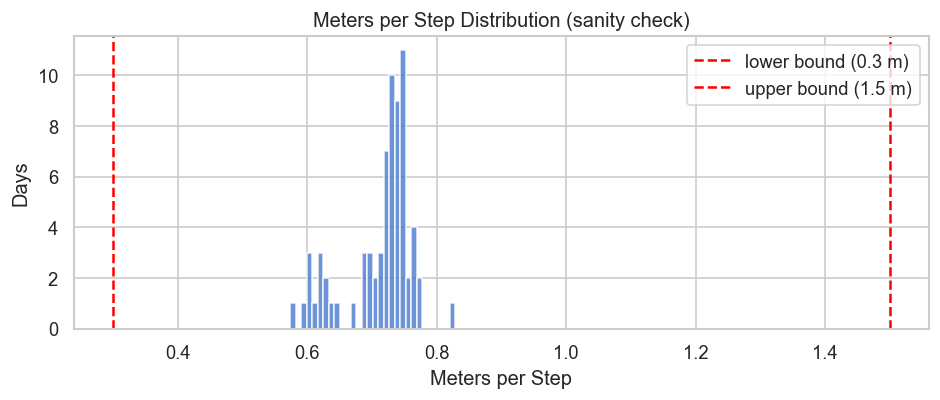

In [190]:
# Meters-per-step histogram (sanity plot)
valid = (gold_core["steps"] > 0) & (gold_core["distance_km"] > 0)
if valid.sum() > 0:
    mps = (gold_core.loc[valid, "distance_km"] * 1000) / gold_core.loc[valid, "steps"]
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(mps, bins=30, edgecolor="white", alpha=0.8)
    ax.axvline(0.3, color="red", ls="--", label="lower bound (0.3 m)")
    ax.axvline(1.5, color="red", ls="--", label="upper bound (1.5 m)")
    ax.set_xlabel("Meters per Step")
    ax.set_ylabel("Days")
    ax.set_title("Meters per Step Distribution (sanity check)")
    ax.legend()
    plt.tight_layout()
    savefig("meters_per_step", kind="prep")
    plt.show()
else:
    print("No valid rows with steps > 0 and distance_km > 0 — skipping histogram.")

---
## PHASE 2: Exploratory Data Analysis (EDA)

### Time-Series Plots — Core Activity Metrics

Each subplot shows the daily trajectory for a core metric. Days with missing values appear as gaps in the lines.

  Saved -> figures/eda_time_series_core.png


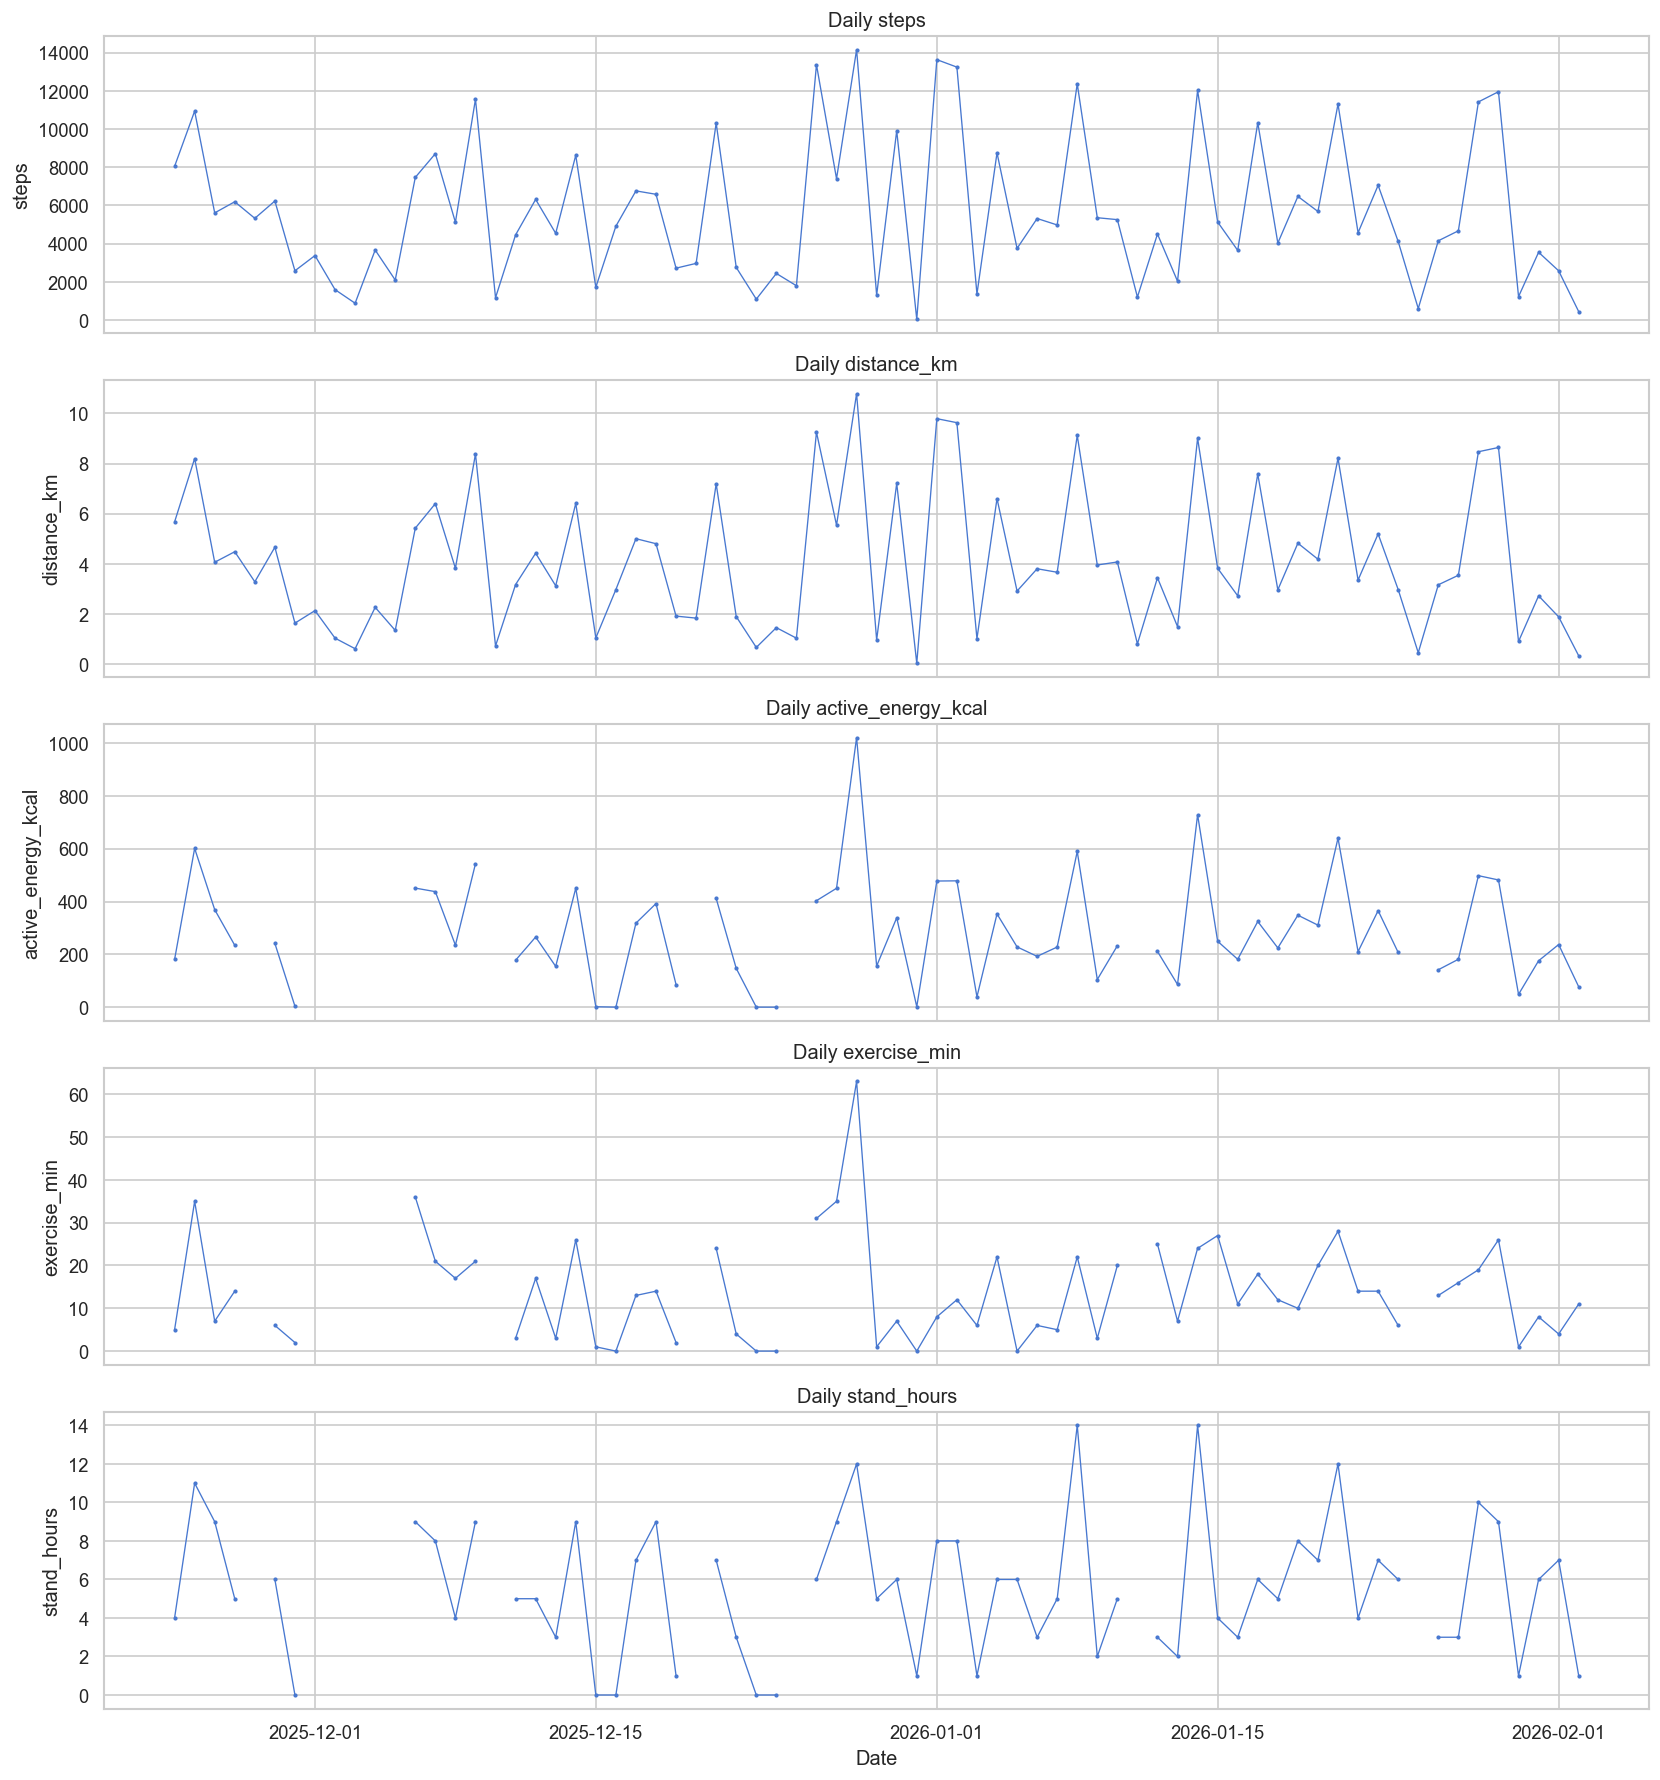

In [191]:
ts_cols = ["steps", "distance_km", "active_energy_kcal", "exercise_min", "stand_hours"]
ts_cols = [c for c in ts_cols if c in gold_core.columns]

if ts_cols:
    fig, axes = plt.subplots(len(ts_cols), 1, figsize=(14, 3 * len(ts_cols)), sharex=True)
    if len(ts_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, ts_cols):
        ax.plot(gold_core["date"], gold_core[col], marker=".", markersize=3, linewidth=0.8)
        ax.set_ylabel(col)
        ax.set_title(f"Daily {col}")
    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    savefig("time_series_core", kind="eda")
    plt.show()
else:
    print("No core time-series columns available.")

**Interpretation:** The daily trajectories show moderate day-to-day variability across all five metrics with no obvious upward or downward secular trend over the ~10-week window. Steps and active energy exhibit roughly synchronized peaks and troughs, consistent with shared underlying activity patterns. Several low-activity days are visible (dips toward zero), likely rest days or incomplete-wear days. No strong weekly periodicity is immediately apparent at this resolution.

### Distributions — Histograms & Boxplots

  Saved -> figures/eda_distributions_core.png


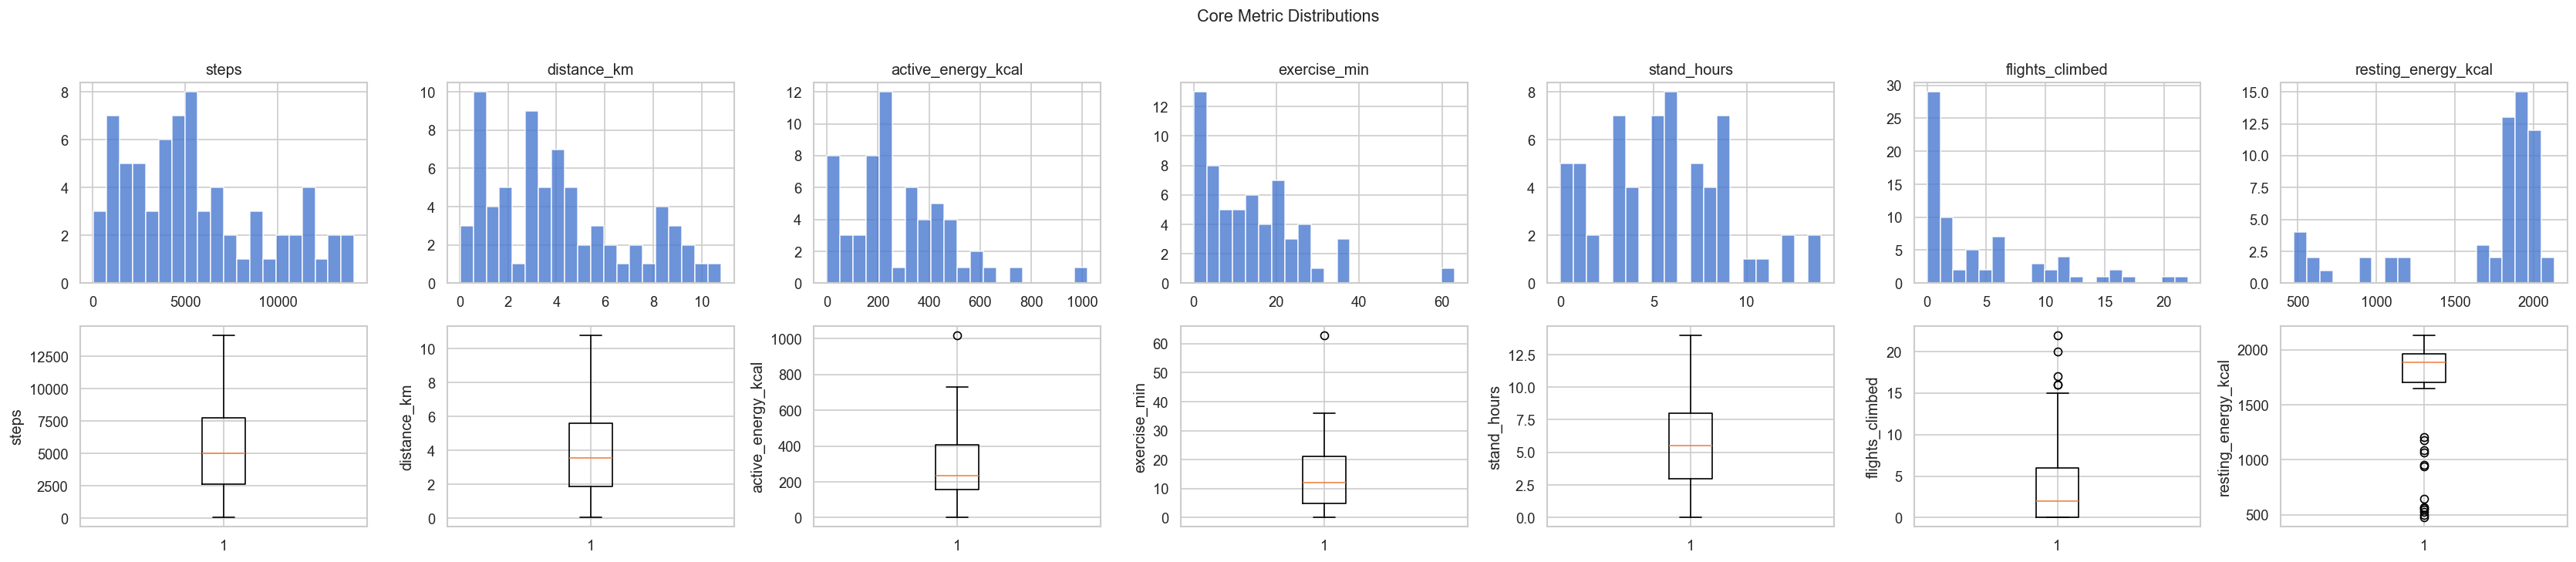

In [192]:
dist_cols = ["steps", "distance_km", "active_energy_kcal", "exercise_min",
             "stand_hours", "flights_climbed", "resting_energy_kcal"]
dist_cols = [c for c in dist_cols if c in gold_core.columns]

if dist_cols:
    fig, axes = plt.subplots(2, len(dist_cols), figsize=(4 * len(dist_cols), 6))
    if len(dist_cols) == 1:
        axes = axes.reshape(2, 1)
    for i, col in enumerate(dist_cols):
        data = gold_core[col].dropna()
        axes[0, i].hist(data, bins=20, edgecolor="white", alpha=0.8)
        axes[0, i].set_title(col)
        axes[1, i].boxplot(data, vert=True)
        axes[1, i].set_ylabel(col)
    fig.suptitle("Core Metric Distributions", fontsize=13, y=1.01)
    plt.tight_layout()
    savefig("distributions_core", kind="eda")
    plt.show()
else:
    print("No distribution columns available.")

**Interpretation:** Most core metrics display roughly symmetric, unimodal distributions. `flights_climbed` is right-skewed with a concentration near zero (many no-flight days). The boxplots for `steps` and `active_energy_kcal` show a handful of upper outliers but no extreme values that would warrant removal. `resting_energy_kcal` is tightly clustered (low variance), consistent with stable basal metabolism over the observation window.

### Relationships — Scatter + Correlation Heatmap

  Saved -> figures/eda_scatter_steps_vs_energy.png


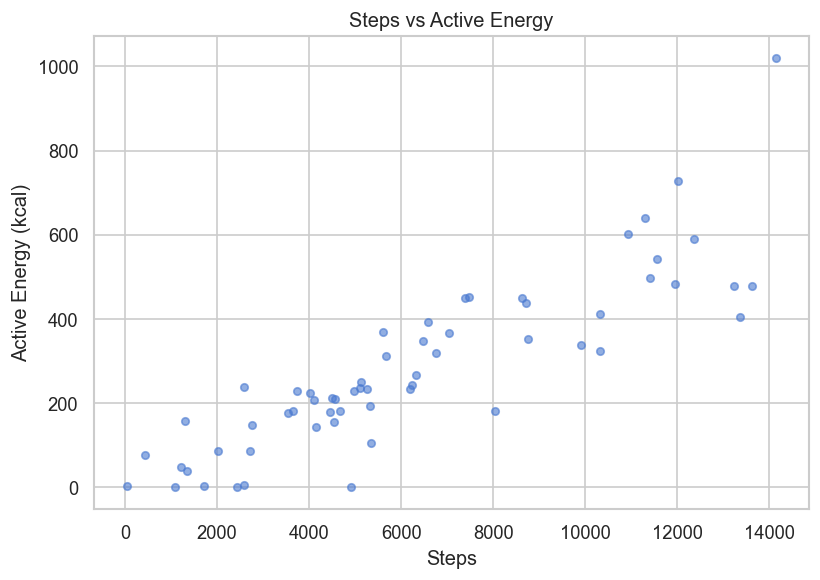

In [193]:
# Scatter: steps vs active_energy_kcal
if "steps" in gold_core.columns and "active_energy_kcal" in gold_core.columns:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(gold_core["steps"], gold_core["active_energy_kcal"], alpha=0.6, s=20)
    ax.set_xlabel("Steps")
    ax.set_ylabel("Active Energy (kcal)")
    ax.set_title("Steps vs Active Energy")
    plt.tight_layout()
    savefig("scatter_steps_vs_energy", kind="eda")
    plt.show()
else:
    print("steps or active_energy_kcal missing — skipping scatter.")

**Interpretation:** The scatter shows a strong positive linear association between daily steps and active energy expenditure. Points cluster tightly around an apparent regression line with no obvious curvature or heteroscedasticity, supporting the use of Pearson correlation in Phase 3. A few low-step, moderate-energy points may reflect non-ambulatory exercise (cycling, strength training) that contributes to energy expenditure without registering additional steps.

  Saved -> figures/eda_correlation_heatmap.png


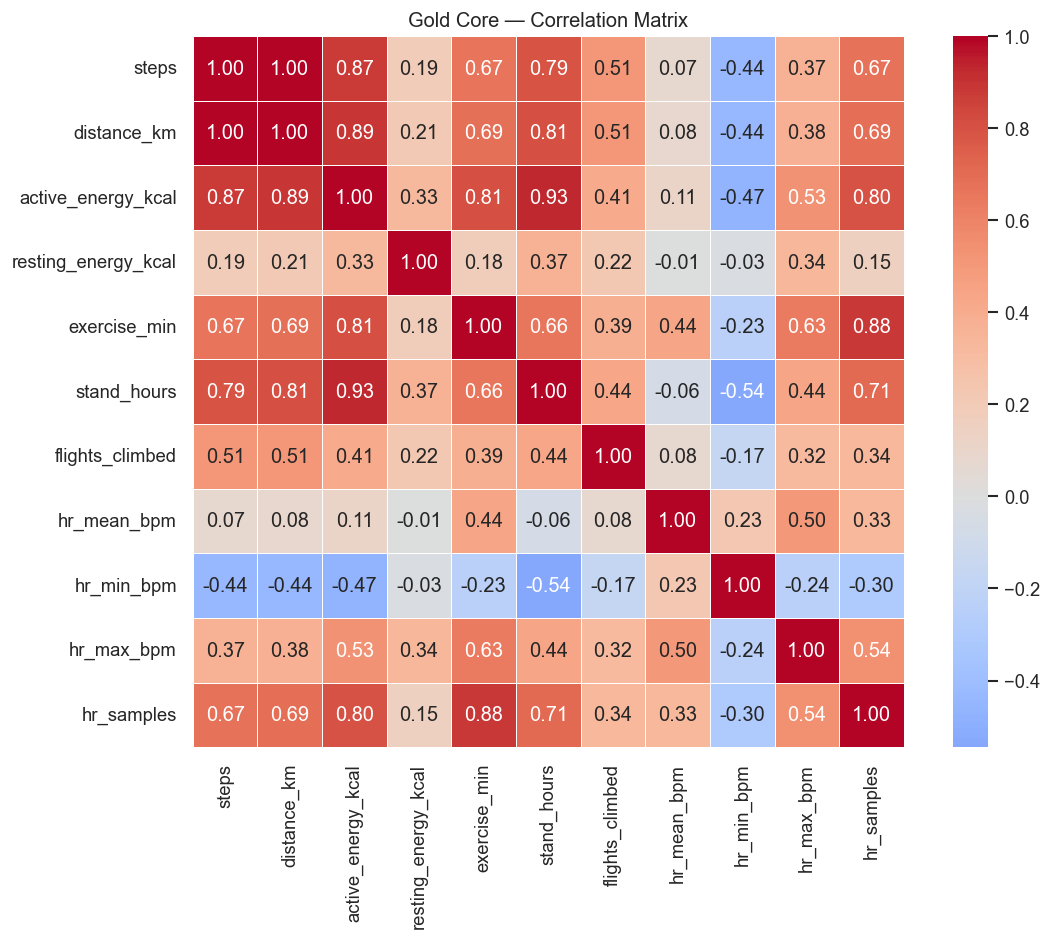

In [194]:
# Correlation heatmap (core numeric columns)
numeric_core = gold_core.select_dtypes(include="number")
if numeric_core.shape[1] > 1:
    corr = numeric_core.corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title("Gold Core — Correlation Matrix")
    plt.tight_layout()
    savefig("correlation_heatmap", kind="eda")
    plt.show()
else:
    print("Not enough numeric columns for a heatmap.")

**Interpretation:** The heatmap reveals a cluster of high positive correlations ($$r > 0.7$$) among movement-derived metrics: steps, distance, active energy, and stand hours — expected since these are co-occurring signals from ambulatory activity. Heart-rate features (mean, min, max, samples) form a secondary correlated group. `resting_energy_kcal` shows near-zero correlation with activity metrics, consistent with it measuring a distinct physiological construct (basal metabolic rate). `flights_climbed` is only moderately correlated with other activity metrics, reflecting its intermittent nature.

In [195]:
# Quick precision check — steps vs distance_km (heatmap shows r=1.00 after rounding)
_pair = gold_core[["steps", "distance_km"]].dropna()
print("Pearson r (full precision):")
print(_pair.corr().to_string(float_format="{:.6f}".format))
print(f"\nSample rows (n={len(_pair)}):")
print(_pair.head(5).to_string())
del _pair

Pearson r (full precision):
               steps  distance_km
steps       1.000000     0.997728
distance_km 0.997728     1.000000

Sample rows (n=71):
     steps  distance_km
0   8042.0         5.67
1  10933.0         8.20
2   5606.0         4.06
3   6189.0         4.48
4   5322.0         3.28


### Missingness Exploration — Extended Physiology Columns

  Saved -> figures/eda_missingness_extended.png


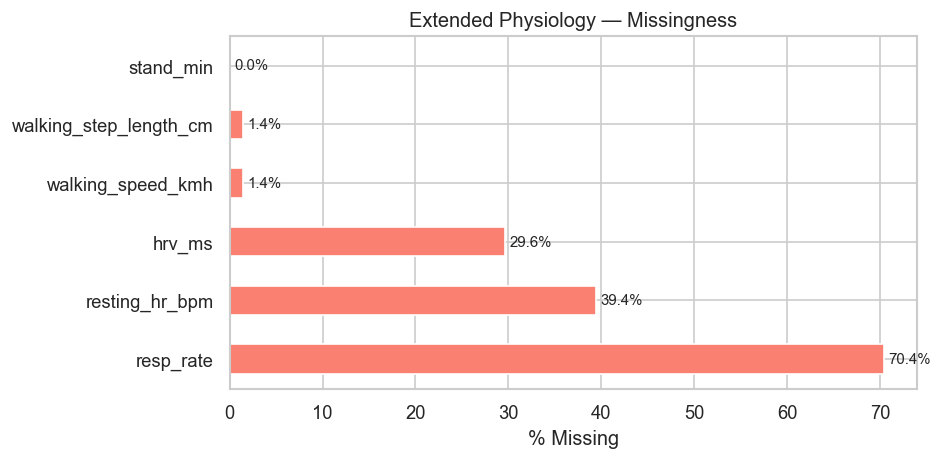

In [196]:
ext_physio = ["hrv_ms", "resp_rate", "resting_hr_bpm",
              "walking_speed_kmh", "walking_step_length_cm", "stand_min"]
ext_physio = [c for c in ext_physio if c in gold_ext.columns]

if ext_physio:
    miss_pct = (gold_ext[ext_physio].isna().mean() * 100).round(1)
    fig, ax = plt.subplots(figsize=(8, 4))
    miss_pct.sort_values(ascending=False).plot.barh(ax=ax, color="salmon", edgecolor="white")
    ax.set_xlabel("% Missing")
    ax.set_title("Extended Physiology — Missingness")
    for i, v in enumerate(miss_pct.sort_values(ascending=False)):
        ax.text(v + 0.5, i, f"{v}%", va="center", fontsize=9)
    plt.tight_layout()
    savefig("missingness_extended", kind="eda")
    plt.show()
else:
    print("No extended physiology columns found in gold_ext.")

**Interpretation:** The missingness bar chart highlights that `resp_rate` (respiratory rate) is the most incomplete extended metric, missing over 70 % of days, followed by `resting_hr_bpm` (~39 %) and `hrv_ms` (~30 %). These high-missingness columns are excluded from the modeling feature set because imputation at these rates would introduce substantial noise. The remaining extended physiology columns (`walking_speed_kmh`, `walking_step_length_cm`) have negligible missingness (~1 %) and could be included in future analyses.

### Phase 2 Summary

The time-series plots reveal moderate day-to-day variability in steps and active energy, with no obvious long-term trend over the observation window. Histograms confirm that most core metrics are roughly symmetric, though `flights_climbed` is right-skewed (many zero-flight days). The scatter plot shows a strong positive linear relationship between steps and active energy, visually supporting the Pearson test in Phase 3. The correlation heatmap reveals high correlations among activity metrics (steps, distance, active energy, stand hours), as expected for co-occurring movement signals. Extended physiology columns (HRV, respiratory rate) have substantial missingness, motivating their exclusion from the modeling feature set.

---
## PHASE 3: Statistical Tests

### Pearson Correlation: Steps vs Active Energy

In [197]:
from scipy import stats

if "steps" in gold_core.columns and "active_energy_kcal" in gold_core.columns:
    pair = gold_core[["steps", "active_energy_kcal"]].dropna()
    r, p = stats.pearsonr(pair["steps"], pair["active_energy_kcal"])
    print(f"Pearson r = {r:.4f},  p-value = {p:.2e}  (n = {len(pair)})")
else:
    print("Required columns missing — skipping Pearson test.")

Pearson r = 0.8733,  p-value = 9.16e-20  (n = 60)


In [198]:
# Shapiro-Wilk normality test (assumption check for Pearson)
from scipy.stats import shapiro

if len(pair) >= 8:
    sw_steps, p_steps = shapiro(pair["steps"])
    sw_energy, p_energy = shapiro(pair["active_energy_kcal"])
    print(f"Shapiro-Wilk — steps:         W = {sw_steps:.4f},  p = {p_steps:.4f}")
    print(f"Shapiro-Wilk — active_energy:  W = {sw_energy:.4f},  p = {p_energy:.4f}")
    print("(p > 0.05 ⇒ consistent with normality; p < 0.05 ⇒ some departure)")
    print("Note: Pearson r is robust to mild non-normality at n ≥ 30.")
else:
    print("Too few rows for Shapiro-Wilk test.")

Shapiro-Wilk — steps:         W = 0.9502,  p = 0.0160
Shapiro-Wilk — active_energy:  W = 0.9360,  p = 0.0036
(p > 0.05 ⇒ consistent with normality; p < 0.05 ⇒ some departure)
Note: Pearson r is robust to mild non-normality at n ≥ 30.


In [199]:
# Spearman rank correlation (robustness check — does not assume normality)
from scipy.stats import spearmanr

rho, p_spearman = spearmanr(pair["steps"], pair["active_energy_kcal"])
print(f"Spearman ρ = {rho:.4f},  p-value = {p_spearman:.2e}  (n = {len(pair)})")
print(f"\nComparison: Pearson r = {r:.4f} vs Spearman ρ = {rho:.4f}")
if abs(r - rho) < 0.05:
    print("→ Near-identical magnitudes confirm the association is robust to")
    print("  the mild normality departures flagged by Shapiro-Wilk.")
else:
    print("→ Meaningful divergence between r and ρ; the relationship may be")
    print("  monotonic but not strictly linear. Interpret Pearson r with caution.")

Spearman ρ = 0.8961,  p-value = 4.04e-22  (n = 60)

Comparison: Pearson r = 0.8733 vs Spearman ρ = 0.8961
→ Near-identical magnitudes confirm the association is robust to
  the mild normality departures flagged by Shapiro-Wilk.


**Interpretation:** A positive Pearson $$r$$ close to 1 indicates a strong linear relationship between daily step count and active energy expenditure. The $$p$$-value tells us whether the correlation is statistically significant. The Spearman rank correlation ($$\rho$$, computed above) serves as a non-parametric robustness check: near-identical magnitude and significance confirm that the association is robust to the mild normality departures flagged by Shapiro-Wilk and does not hinge on strict linearity assumptions.

### Weekend vs Weekday: Welch's t-test on Active Energy

In [200]:
if "active_energy_kcal" in gold_core.columns:
    gc = gold_core.copy()
    gc["date"] = pd.to_datetime(gc["date"])
    gc["is_weekend"] = gc["date"].dt.dayofweek >= 5  # Sat=5, Sun=6

    weekday_energy = gc.loc[~gc["is_weekend"], "active_energy_kcal"].dropna()
    weekend_energy = gc.loc[ gc["is_weekend"], "active_energy_kcal"].dropna()

    t_stat, p_val = stats.ttest_ind(weekday_energy, weekend_energy, equal_var=False)

    print(f"Weekday  n={len(weekday_energy)}, mean={weekday_energy.mean():.1f} kcal")
    print(f"Weekend  n={len(weekend_energy)}, mean={weekend_energy.mean():.1f} kcal")
    print(f"Welch t = {t_stat:.3f},  p-value = {p_val:.4f}")
else:
    print("active_energy_kcal missing — skipping t-test.")

Weekday  n=43, mean=267.6 kcal
Weekend  n=17, mean=318.4 kcal
Welch t = -0.813,  p-value = 0.4239


In [201]:
# Cohen's d effect size (magnitude of difference, regardless of significance)
n_wd, n_we = len(weekday_energy), len(weekend_energy)
pooled_std = np.sqrt(((n_wd - 1) * weekday_energy.std()**2 +
                      (n_we - 1) * weekend_energy.std()**2) /
                     (n_wd + n_we - 2))
cohens_d = (weekday_energy.mean() - weekend_energy.mean()) / pooled_std
print(f"Cohen's d = {cohens_d:.3f}")
print("  (|d| < 0.2 = negligible,  0.2–0.5 = small,  0.5–0.8 = medium,  > 0.8 = large)")

Cohen's d = -0.252
  (|d| < 0.2 = negligible,  0.2–0.5 = small,  0.5–0.8 = medium,  > 0.8 = large)


**Interpretation:** If $$p < 0.05$$, we would conclude that weekday and weekend active energy differ significantly; if $$p \geq 0.05$$, the difference is not statistically significant at the chosen threshold. The direction of the $$t$$-statistic tells us which group has the higher mean. Cohen's $$d$$ quantifies the practical magnitude of the difference regardless of significance.

---
## PHASE 4: Modeling

**Target:** `active_energy_kcal` (daily active energy burned)

**Approach:** Same-day explanatory modeling with a chronological train/test split (to prevent look-ahead leakage). Features include same-day activity/physiology metrics plus a small set of lag-1 features for historical context.

### Feature Engineering

In [202]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

TARGET = "active_energy_kcal"

mdf = gold_core.copy()
mdf["date"] = pd.to_datetime(mdf["date"])
mdf = mdf.sort_values("date").reset_index(drop=True)

# Lag-1 features (yesterday's values — no leakage)
lag_cols = ["steps", "exercise_min", "active_energy_kcal"]
lag_cols = [c for c in lag_cols if c in mdf.columns]
for c in lag_cols:
    mdf[f"{c}_lag1"] = mdf[c].shift(1)

# Day-of-week one-hot encoding
mdf["dow"] = mdf["date"].dt.dayofweek
mdf = pd.get_dummies(mdf, columns=["dow"], prefix="dow", drop_first=True)

# Drop ALL rows with any NaN (target, lags, and other features like HR/energy
# that may be NaN after suspicious-zero conversion). This ensures sklearn
# models that don't accept NaN (LinearRegression) work cleanly.
feature_cols = [c for c in mdf.columns if c not in ["date", TARGET]]
mdf = mdf.dropna(subset=[TARGET] + feature_cols).reset_index(drop=True)

X = mdf[feature_cols]
y = mdf[TARGET]

print(f"Modeling rows: {len(mdf)},  Features: {X.shape[1]}")
print(f"Feature list: {feature_cols}")

Modeling rows: 46,  Features: 19
Feature list: ['steps', 'distance_km', 'resting_energy_kcal', 'exercise_min', 'stand_hours', 'flights_climbed', 'hr_mean_bpm', 'hr_min_bpm', 'hr_max_bpm', 'hr_samples', 'steps_lag1', 'exercise_min_lag1', 'active_energy_kcal_lag1', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']


In [203]:
# Dropped-Date Audit: which dates did dropna() remove? 
all_dates = set(gold_core["date"].dt.date)
kept_dates = set(mdf["date"].dt.date)
dropped_dates = sorted(all_dates - kept_dates)

print(f"Rows before dropna: {len(gold_core)}")
print(f"Rows after  dropna: {len(mdf)}")
print(f"Dropped: {len(dropped_dates)} dates\n")

if dropped_dates:
    print(f"  Earliest dropped: {dropped_dates[0]}")
    print(f"  Latest  dropped:  {dropped_dates[-1]}")
    print(f"  All dropped dates: {dropped_dates}\n")

    # Check whether drops cluster in the first third of the study period
    study_start = min(all_dates)
    study_end   = max(all_dates)
    study_range = (study_end - study_start).days
    first_third_cutoff = study_start + pd.Timedelta(days=study_range // 3)
    n_in_first_third = sum(1 for d in dropped_dates if d <= first_third_cutoff)
    pct_first_third = n_in_first_third / len(dropped_dates) * 100
    print(f"  First third of study (≤ {first_third_cutoff}): "
          f"{n_in_first_third}/{len(dropped_dates)} dropped dates ({pct_first_third:.0f}%)")
    if pct_first_third > 60:
        print("  → Drops are concentrated early (likely device warm-up / incomplete wear).")
        print("    The modeled sample is representative of the mature data-collection phase.")
    else:
        print("  → Drops are spread across the study period (scattered missingness).")
else:
    print("  No dates dropped — all rows are complete.")

Rows before dropna: 71
Rows after  dropna: 46
Dropped: 25 dates

  Earliest dropped: 2025-11-24
  Latest  dropped:  2026-01-26
  All dropped dates: [datetime.date(2025, 11, 24), datetime.date(2025, 11, 28), datetime.date(2025, 11, 29), datetime.date(2025, 11, 30), datetime.date(2025, 12, 1), datetime.date(2025, 12, 2), datetime.date(2025, 12, 3), datetime.date(2025, 12, 4), datetime.date(2025, 12, 5), datetime.date(2025, 12, 6), datetime.date(2025, 12, 10), datetime.date(2025, 12, 11), datetime.date(2025, 12, 15), datetime.date(2025, 12, 16), datetime.date(2025, 12, 20), datetime.date(2025, 12, 21), datetime.date(2025, 12, 23), datetime.date(2025, 12, 24), datetime.date(2025, 12, 25), datetime.date(2025, 12, 26), datetime.date(2026, 1, 7), datetime.date(2026, 1, 11), datetime.date(2026, 1, 12), datetime.date(2026, 1, 25), datetime.date(2026, 1, 26)]

  First third of study (≤ 2025-12-17): 14/25 dropped dates (56%)
  → Drops are spread across the study period (scattered missingness).


### Chronological Train/Test Split (80/20)

In [204]:
split_idx = int(len(mdf) * 0.8)

train = mdf.iloc[:split_idx]
test  = mdf.iloc[split_idx:]

X_train, y_train = train[feature_cols], train[TARGET]
X_test,  y_test  = test[feature_cols],  test[TARGET]

print(f"Train: {len(train)} rows  ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Test : {len(test)} rows  ({test['date'].min().date()} → {test['date'].max().date()})")

Train: 36 rows  (2025-11-25 → 2026-01-21)
Test : 10 rows  (2026-01-22 → 2026-02-02)


In [205]:
# NaN "at-fit-time" 
# Assertions — ensure no NaNs in the final modeling inputs (after all feature engineering and dropping).
def assert_no_nans(df, name="X"):
    """Raise if any NaN in a DataFrame/Series; print column-level detail."""
    nans_per_col = df.isna().sum() if hasattr(df, "columns") else pd.Series({"value": df.isna().sum()})
    bad = nans_per_col[nans_per_col > 0]
    if len(bad) > 0:
        raise AssertionError(
            f"{name} contains NaNs in columns:\n{bad.to_string()}\n"
            f"Total NaNs in {name}: {int(df.isna().sum().sum() if hasattr(df, 'columns') else df.isna().sum())}"
        )
    shape = df.shape if hasattr(df, "columns") else (len(df),)
    print(f"✅ {name}: no NaNs (shape={shape})")

assert_no_nans(X_train, "X_train")
assert_no_nans(X_test,  "X_test")
assert_no_nans(y_train.to_frame(), "y_train")
assert_no_nans(y_test.to_frame(),  "y_test")

print(f"\n✅ All fit-time inputs are NaN-free. Models will not receive missing values.")

✅ X_train: no NaNs (shape=(36, 19))
✅ X_test: no NaNs (shape=(10, 19))
✅ y_train: no NaNs (shape=(36, 1))
✅ y_test: no NaNs (shape=(10, 1))

✅ All fit-time inputs are NaN-free. Models will not receive missing values.


### Model Training & Evaluation

**Hyperparameter note:** `n_estimators=500` is a deliberately conservative choice — OOB error curves for Random Forest typically plateau well before 500 trees for datasets of this size (~36 training rows, 19 features). Using more trees than strictly necessary ensures variance reduction without risk of overfitting (RF ensembles do not overfit with additional trees). No further hyperparameter tuning (max_depth, min_samples_leaf, etc.) was performed, which trades a small amount of potential performance for simplicity and reduced risk of over-optimising on a 10-row test set.

In [206]:
results = {}

# --- Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = pd.Series(lr.predict(X_test), index=y_test.index, name="lr_pred")
results["LinearRegression"] = {
    "MAE": mean_absolute_error(y_test, lr_pred),
    "R2":  r2_score(y_test, lr_pred),
}

# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=500, random_state=RANDOM_SEED)
rf.fit(X_train, y_train)
rf_pred = pd.Series(rf.predict(X_test), index=y_test.index, name="rf_pred")
results["RandomForest"] = {
    "MAE": mean_absolute_error(y_test, rf_pred),
    "R2":  r2_score(y_test, rf_pred),
}

# --- Summary table ---
res_df = pd.DataFrame(results).T
res_df["MAE"] = res_df["MAE"].round(2)
res_df["R2"]  = res_df["R2"].round(4)
print(res_df.to_string())

                    MAE      R2
LinearRegression  50.37  0.8619
RandomForest      29.19  0.9448


### Baseline Comparisons (Dummy Mean + Naive Yesterday)

In [207]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Baseline 1: DummyRegressor (predict training-set mean)
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
dummy_pred = pd.Series(dummy.predict(X_test), index=y_test.index, name="dummy_pred")
results["Dummy (mean)"] = {
    "MAE": mean_absolute_error(y_test, dummy_pred),
    "R2":  r2_score(y_test, dummy_pred),
}

# Baseline 2: Naive yesterday (y_{t-1} predicts y_t)
# For each test row, use the preceding day's observed active_energy_kcal.
# The first test row's "yesterday" is the last training row.
naive_yesterday = pd.concat([train.iloc[[-1]], test])[[TARGET]].shift(1).iloc[1:]
# naive_yesterday now has the same index as test (all 10 rows).
naive_pred = pd.Series(naive_yesterday[TARGET].values, index=y_test.index, name="naive_pred")

# Check for any NaN in naive predictions (would only happen if last train row is NaN)
naive_mask = ~np.isnan(naive_pred)
if naive_mask.all():
    results["Naive (yesterday)"] = {
        "MAE": mean_absolute_error(y_test, naive_pred),
        "R2":  r2_score(y_test, naive_pred),
    }
    print("Naive baseline: all test rows have a valid yesterday value.")
else:
    n_valid = naive_mask.sum()
    results["Naive (yesterday)"] = {
        "MAE": mean_absolute_error(y_test[naive_mask], naive_pred[naive_mask]),
        "R2":  r2_score(y_test[naive_mask], naive_pred[naive_mask]),
    }
    print(f"Naive baseline: {n_valid}/{len(y_test)} test rows used "
          f"({len(y_test) - n_valid} dropped — yesterday's value missing).")

# Combined comparison table
comp_df = pd.DataFrame(results).T[["MAE", "R2"]]
comp_df["MAE"] = comp_df["MAE"].round(2)
comp_df["R2"]  = comp_df["R2"].round(4)
comp_df = comp_df.sort_values("MAE", ascending=True)
print("\n=== Model Comparison (sorted by MAE) ===")
print(comp_df.to_string())

Naive baseline: all test rows have a valid yesterday value.

=== Model Comparison (sorted by MAE) ===
                      MAE      R2
RandomForest        29.19  0.9448
LinearRegression    50.37  0.8619
Dummy (mean)       153.99 -0.3381
Naive (yesterday)  188.39 -1.6713


### Random Forest — Feature Importance (Top 15)

  Saved -> figures/model_rf_feature_importance.png


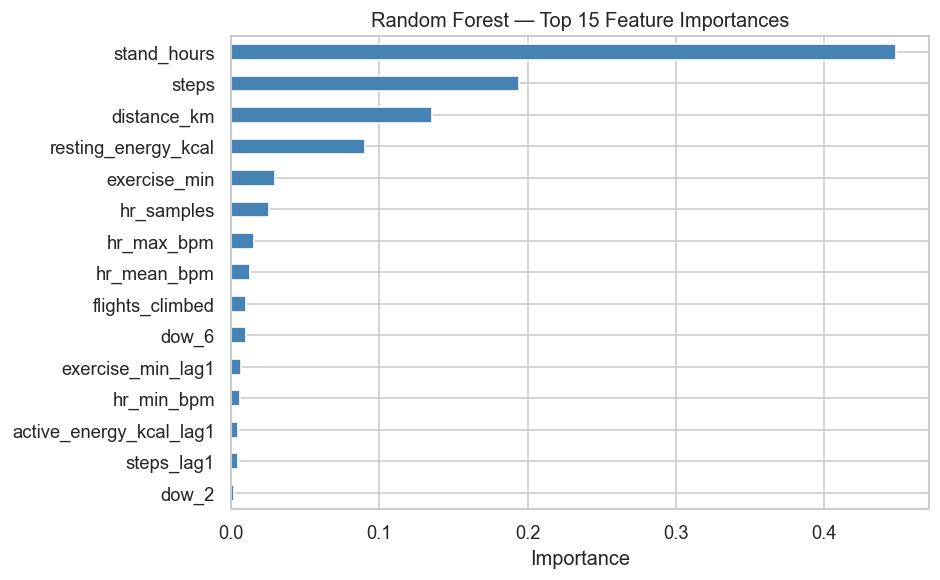

In [209]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
top15.sort_values().plot.barh(ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Importance")
ax.set_title("Random Forest — Top 15 Feature Importances")
plt.tight_layout()
savefig("rf_feature_importance", kind="model")
plt.show()

### Robustness Checks: Leakage Audit, Ablations, and Time-Series CV

In [210]:
# Split Integrity & Defensibility Audit
from collections import OrderedDict

checks = OrderedDict()

# A) Index alignment + chronological split
train_max = train["date"].max()
test_min  = test["date"].min()
chrono_ok  = train_max < test_min
idx_ok     = X_train.index.equals(y_train.index) and X_test.index.equals(y_test.index)
no_overlap = len(set(X_train.index) & set(X_test.index)) == 0
nan_free   = (X_train.isna().sum().sum() + X_test.isna().sum().sum()
              + y_train.isna().sum() + y_test.isna().sum()) == 0
tgt_safe   = TARGET not in feature_cols

checks["Dates unique & sorted"]  = mdf["date"].is_unique and mdf["date"].is_monotonic_increasing
checks["Target ∉ features"]      = tgt_safe
checks["Chronological split"]    = chrono_ok
checks["Index alignment (X↔y)"]  = idx_ok
checks["No train/test overlap"]  = no_overlap
checks["NaN-free at fit-time"]   = nan_free
# Guard: abl_df is built in a later cell; skip this check on first run
checks["Uniform ablation n_test"] = (
    ("abl_df" in globals()) and len(abl_df["n_test"].unique()) == 1
)

print("=== Defensibility Audit ===")
print(f"  Train: n={len(train)} | {train['date'].min().date()} → {train_max.date()}")
print(f"  Test:  n={len(test)}  | {test_min.date()} → {test['date'].max().date()}")
for label, passed in checks.items():
    print(f"  {'✅' if passed else '❌'} {label}")
all_pass = all(checks.values())
print(f"\n{'✅ ALL CHECKS PASSED' if all_pass else '❌ SOME CHECKS FAILED'}")

=== Defensibility Audit ===
  Train: n=36 | 2025-11-25 → 2026-01-21
  Test:  n=10  | 2026-01-22 → 2026-02-02
  ✅ Dates unique & sorted
  ✅ Target ∉ features
  ✅ Chronological split
  ✅ Index alignment (X↔y)
  ✅ No train/test overlap
  ✅ NaN-free at fit-time
  ✅ Uniform ablation n_test

✅ ALL CHECKS PASSED


In [211]:
# Feature Audit: Leakage Guardrail
print("=== Feature Audit ===")
print(f"Target column: {TARGET}\n")
print(f"Feature columns ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

# Categorised flags
direct_leakage   = []   # exact target name in features
autoregressive   = []   # lag of target — not leakage in same-day model
same_family      = []   # related metric (e.g. resting_energy_kcal)

leakage_keywords = ["active_energy", "calorie", "energy", "target", "label"]

for col in feature_cols:
    cl = col.lower()
    if cl == TARGET.lower():
        direct_leakage.append(col)
    elif "lag" in cl and any(kw in cl for kw in leakage_keywords):
        autoregressive.append(col)
    elif any(kw in cl for kw in leakage_keywords):
        same_family.append(col)

print("\nFlag Summary ──")
if direct_leakage:
    print(f"  🔴  DIRECT LEAKAGE (exact target in X): {direct_leakage}")
    print("       ➜ This must be removed before modeling!")
else:
    print("  ✅  No direct leakage (target column not in feature set).")

if autoregressive:
    print(f"  🟡  AUTOREGRESSIVE (target lag): {autoregressive}")
    print("       ➜ Uses yesterday's value via .shift(1). Not leakage in a")
    print("         same-day explanatory model; provides autoregressive context.")
    print("         The ablation study below quantifies their contribution.")
else:
    print("  ✅  No autoregressive target-lag features.")

if same_family:
    print(f"  🟡  SAME-FAMILY / CORRELATED: {same_family}")
    print("       ➜ Related metric(s), but NOT the target itself.")
    print("         e.g. resting_energy_kcal = basal metabolic rate (distinct")
    print("         Apple Health measure that does not include active energy).")
    print("         Retained as a legitimate predictor.")
else:
    print("  ✅  No same-family keyword matches.")

=== Feature Audit ===
Target column: active_energy_kcal

Feature columns (19):
   1. steps
   2. distance_km
   3. resting_energy_kcal
   4. exercise_min
   5. stand_hours
   6. flights_climbed
   7. hr_mean_bpm
   8. hr_min_bpm
   9. hr_max_bpm
  10. hr_samples
  11. steps_lag1
  12. exercise_min_lag1
  13. active_energy_kcal_lag1
  14. dow_1
  15. dow_2
  16. dow_3
  17. dow_4
  18. dow_5
  19. dow_6

Flag Summary ──
  ✅  No direct leakage (target column not in feature set).
  🟡  AUTOREGRESSIVE (target lag): ['active_energy_kcal_lag1']
       ➜ Uses yesterday's value via .shift(1). Not leakage in a
         same-day explanatory model; provides autoregressive context.
         The ablation study below quantifies their contribution.
  🟡  SAME-FAMILY / CORRELATED: ['resting_energy_kcal']
       ➜ Related metric(s), but NOT the target itself.
         e.g. resting_energy_kcal = basal metabolic rate (distinct
         Apple Health measure that does not include active energy).
         Ret

In [212]:
# Ablation Helper
def evaluate_feature_set(config_name, cols, X_train, X_test, y_train, y_test,
                          expected_n_test, random_seed=42):
    """Evaluate RandomForest + LinearRegression on a feature subset.

    Returns
    -------
    rows : list[dict]  — one dict per model with MAE, R², etc.
    was_skipped : bool  — True if the config was skipped (NaN guard).
    """
    X_tr_ab, X_te_ab = X_train[cols], X_test[cols]

    # Guard: confirm no NaN introduced by column subset
    bad_tr = X_tr_ab.isna().sum().pipe(lambda s: s[s > 0])
    bad_te = X_te_ab.isna().sum().pipe(lambda s: s[s > 0])
    if len(bad_tr) > 0 or len(bad_te) > 0:
        print(f"\n SKIPPING '{config_name}' — NaN introduced in:")
        if len(bad_tr) > 0: print(f"    Train: {dict(bad_tr)}")
        if len(bad_te) > 0: print(f"    Test:  {dict(bad_te)}")
        print("    (Rows would need to be dropped, breaking row-consistency.)")
        return [], True

    assert len(X_te_ab) == expected_n_test, (
        f"Row mismatch in '{config_name}': expected {expected_n_test} test rows.")

    rows = []
    for ModelClass, model_name in [(RandomForestRegressor, "RandomForest"),
                                    (LinearRegression, "LinearRegression")]:
        kw = dict(n_estimators=500, random_state=random_seed) if model_name == "RandomForest" else {}
        model = ModelClass(**kw)
        model.fit(X_tr_ab, y_train)
        pred = model.predict(X_te_ab)
        rows.append({
            "feature_set": config_name, "model": model_name,
            "MAE": round(mean_absolute_error(y_test, pred), 2),
            "R2":  round(r2_score(y_test, pred), 4),
            "n_test": len(y_test),
        })
    return rows, False

print("✅ evaluate_feature_set() defined.")

✅ evaluate_feature_set() defined.


In [213]:
# Ablation Study
# Hard rule: every configuration uses exactly X_train / X_test rows.
# Only columns change; rows never change.

EXPECTED_N_TEST = len(X_test)
ablation_configs = {}

# 1. Full features (current)
ablation_configs["Full (all features)"] = list(feature_cols)

# 2. No lag features — robust case-insensitive check
lag_removed = [c for c in feature_cols if "lag" in c.lower()]
no_lag = [c for c in feature_cols if "lag" not in c.lower()]
if lag_removed:
    ablation_configs["No lag features"] = no_lag
    print(f"'No lag features' — removed {len(lag_removed)} columns: {lag_removed}")
else:
    print("No lag columns found; skipping 'No lag features' config.")

# 3. Drop individual dominant activity drivers
steps_cols   = [c for c in feature_cols if c == "steps"]
dist_cols_ab = [c for c in feature_cols if "distance" in c.lower() and "lag" not in c.lower()]
exer_cols    = [c for c in feature_cols if "exercise" in c.lower() and "lag" not in c.lower()]

if steps_cols:
    ablation_configs["Drop steps"] = [c for c in feature_cols if c not in steps_cols]
if dist_cols_ab:
    ablation_configs["Drop distance"] = [c for c in feature_cols if c not in dist_cols_ab]
if exer_cols:
    ablation_configs["Drop exercise_min"] = [c for c in feature_cols if c not in exer_cols]

# 4. Drop ALL activity drivers together
activity_drivers = list(set(steps_cols + dist_cols_ab + exer_cols))
if activity_drivers:
    ablation_configs["Drop activity drivers"] = [
        c for c in feature_cols if c not in activity_drivers
    ]

# 5. Physiology-only (HR, resting HR, stand hours, flights — if present)
physio_kw = ["hr", "resting", "stand", "flight"]
physio_cols = [c for c in feature_cols
               if any(kw in c.lower() for kw in physio_kw)
               and "lag" not in c.lower()]
if physio_cols:
    ablation_configs["Physiology only"] = physio_cols

# Evaluate each configuration (via helper)
ablation_rows = []
skipped = []

for config_name, cols in ablation_configs.items():
    result_rows, was_skipped = evaluate_feature_set(
        config_name, cols, X_train, X_test, y_train, y_test,
        EXPECTED_N_TEST, RANDOM_SEED)
    if was_skipped:
        skipped.append(config_name)
    else:
        ablation_rows.extend(result_rows)

# Append baselines (feature-independent)
for bl_name, bl_pred in [("Dummy (mean)", dummy_pred), ("Naive (yesterday)", naive_pred)]:
    ablation_rows.append({
        "feature_set": "— (baseline)", "model": bl_name,
        "MAE": round(mean_absolute_error(y_test, bl_pred), 2),
        "R2":  round(r2_score(y_test, bl_pred), 4),
        "n_test": EXPECTED_N_TEST,
    })

abl_df = pd.DataFrame(ablation_rows)
print("\n=== Ablation Study: Feature-Set Comparison ===")
print(abl_df.to_string(index=False))

# Verify uniform n_test
n_test_vals = abl_df["n_test"].unique()
if len(n_test_vals) == 1 and n_test_vals[0] == EXPECTED_N_TEST:
    print(f"\n✅ All rows evaluated on the same {EXPECTED_N_TEST}-row test set.")
else:
    print(f"\n❌ n_test varies: {sorted(n_test_vals)} — investigate row consistency!")

if skipped:
    print(f"\n Skipped configs (NaN issue): {skipped}")

'No lag features' — removed 3 columns: ['steps_lag1', 'exercise_min_lag1', 'active_energy_kcal_lag1']

=== Ablation Study: Feature-Set Comparison ===
          feature_set             model    MAE      R2  n_test
  Full (all features)      RandomForest  29.19  0.9448      10
  Full (all features)  LinearRegression  50.37  0.8619      10
      No lag features      RandomForest  26.29  0.9549      10
      No lag features  LinearRegression  29.71  0.9442      10
           Drop steps      RandomForest  31.58  0.9359      10
           Drop steps  LinearRegression  48.56  0.8711      10
        Drop distance      RandomForest  29.52  0.9440      10
        Drop distance  LinearRegression  50.18  0.8631      10
    Drop exercise_min      RandomForest  26.87  0.9490      10
    Drop exercise_min  LinearRegression  45.19  0.8680      10
Drop activity drivers      RandomForest  46.09  0.8254      10
Drop activity drivers  LinearRegression  78.81  0.5107      10
      Physiology only      Rand

In [214]:
# Ablation Interpretation
print("=== Interpretation ===")
full_rf = abl_df[(abl_df["feature_set"] == "Full (all features)")
                 & (abl_df["model"] == "RandomForest")].iloc[0]
print(f"• Full Random Forest baseline: MAE = {full_rf['MAE']}, R² = {full_rf['R2']}")

if "No lag features" in ablation_configs and "No lag features" not in skipped:
    nl = abl_df[(abl_df["feature_set"] == "No lag features")
                & (abl_df["model"] == "RandomForest")].iloc[0]
    d = full_rf["R2"] - nl["R2"]
    if d < 0:
        print(f"• Removing lag features ({lag_removed}): R² changes by {d:+.4f} → "
              f"lag features provide no additional explanatory power and slightly "
              f"degrade performance (expected in a same-day model where concurrent "
              f"activity metrics dominate).")
    else:
        word = "minimal" if abs(d) < 0.02 else ("moderate" if abs(d) < 0.05 else "substantial")
        print(f"• Removing lag features ({lag_removed}): R² changes by {d:+.4f} → "
              f"{word} contribution from lag features.")

if "Drop activity drivers" in ablation_configs and "Drop activity drivers" not in skipped:
    da = abl_df[(abl_df["feature_set"] == "Drop activity drivers")
                & (abl_df["model"] == "RandomForest")].iloc[0]
    d = full_rf["R2"] - da["R2"]
    if d > 0.05:
        msg = "Performance degrades substantially, indicating activity metrics are the primary predictors."
    else:
        msg = "Performance holds up, suggesting other features also carry strong signal."
    print(f"• Removing steps + distance + exercise: R² = {da['R2']} (Δ = {d:+.4f}). {msg}")

if "Physiology only" in ablation_configs and "Physiology only" not in skipped:
    ph = abl_df[(abl_df["feature_set"] == "Physiology only")
                & (abl_df["model"] == "RandomForest")].iloc[0]
    print(f"• Physiology-only R² = {ph['R2']} — "
          + ("limited explanatory power alone, as expected."
             if ph["R2"] < 0.5 else "moderate standalone signal."))

# Check if any subset beats full
best = abl_df[abl_df["model"] == "RandomForest"]["R2"].max()
if best <= full_rf["R2"]:
    print("• No feature subset outperforms the full set — high R² is not an artifact "
          "of a single leaky or dominant feature.")
else:
    best_row = abl_df[(abl_df["model"] == "RandomForest")
                      & (abl_df["R2"] == best)].iloc[0]
    print(f"• Best subset: '{best_row['feature_set']}' (R²={best:.4f}) marginally "
          f"beats the full set (R²={full_rf['R2']:.4f}), indicating the removed "
          f"features added noise rather than signal — no leakage concern.")

=== Interpretation ===
• Full Random Forest baseline: MAE = 29.19, R² = 0.9448
• Removing lag features (['steps_lag1', 'exercise_min_lag1', 'active_energy_kcal_lag1']): R² changes by -0.0101 → lag features provide no additional explanatory power and slightly degrade performance (expected in a same-day model where concurrent activity metrics dominate).
• Removing steps + distance + exercise: R² = 0.8254 (Δ = +0.1194). Performance degrades substantially, indicating activity metrics are the primary predictors.
• Physiology-only R² = 0.8444 — moderate standalone signal.
• Best subset: 'No lag features' (R²=0.9549) marginally beats the full set (R²=0.9448), indicating the removed features added noise rather than signal — no leakage concern.


In [215]:
# Time-Series Cross-Validation
from sklearn.model_selection import TimeSeriesSplit

n_splits = 5
# Reduce splits if dataset too small for 5-fold walk-forward
min_fold_size = 3  # minimum test-fold rows for meaningful evaluation
if len(X) < n_splits * min_fold_size + n_splits:
    n_splits = max(2, (len(X) - min_fold_size) // (min_fold_size + 1))
    print(f"NOTE: Reduced to {n_splits} splits due to small dataset ({len(X)} rows).")
else:
    print(f"Using {n_splits} walk-forward folds on {len(X)} rows.")

tscv = TimeSeriesSplit(n_splits=n_splits)

cv_results = {name: {"MAE": [], "R2": []}
              for name in ["RandomForest", "LinearRegression", "Dummy (mean)"]}

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    # Sanity: train indices must all come before test indices (no future leak)
    assert train_idx.max() < test_idx.min(), (
        f"Fold {fold}: train leaks into test! max(train)={train_idx.max()}, "
        f"min(test)={test_idx.min()}"
    )

    X_tr_cv, X_te_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_tr_cv, y_te_cv = y.iloc[train_idx], y.iloc[test_idx]

    # Random Forest — fit on train fold only
    rf_cv = RandomForestRegressor(n_estimators=500, random_state=RANDOM_SEED)
    rf_cv.fit(X_tr_cv, y_tr_cv)
    rf_cv_pred = rf_cv.predict(X_te_cv)
    cv_results["RandomForest"]["MAE"].append(mean_absolute_error(y_te_cv, rf_cv_pred))
    cv_results["RandomForest"]["R2"].append(r2_score(y_te_cv, rf_cv_pred))

    # Linear Regression — fit on train fold only
    lr_cv = LinearRegression()
    lr_cv.fit(X_tr_cv, y_tr_cv)
    lr_cv_pred = lr_cv.predict(X_te_cv)
    cv_results["LinearRegression"]["MAE"].append(mean_absolute_error(y_te_cv, lr_cv_pred))
    cv_results["LinearRegression"]["R2"].append(r2_score(y_te_cv, lr_cv_pred))

    # Dummy (mean) — fit on train fold only
    dummy_cv = DummyRegressor(strategy="mean")
    dummy_cv.fit(X_tr_cv, y_tr_cv)
    dummy_cv_pred = dummy_cv.predict(X_te_cv)
    cv_results["Dummy (mean)"]["MAE"].append(mean_absolute_error(y_te_cv, dummy_cv_pred))
    cv_results["Dummy (mean)"]["R2"].append(r2_score(y_te_cv, dummy_cv_pred))

    print(f"  Fold {fold}: train={len(train_idx)}, test={len(test_idx)} "
          f"  [idx {train_idx[0]}–{train_idx[-1]} → {test_idx[0]}–{test_idx[-1]}]")

# Summary table
cv_rows = []
for name, metrics in cv_results.items():
    cv_rows.append({
        "model": name,
        "MAE_mean": round(np.mean(metrics["MAE"]), 2),
        "MAE_std":  round(np.std(metrics["MAE"]), 2),
        "R2_mean":  round(np.mean(metrics["R2"]), 4),
        "R2_std":   round(np.std(metrics["R2"]), 4),
        "n_folds":  n_splits,
    })

cv_df = pd.DataFrame(cv_rows)
print(f"\n=== Time-Series Cross-Validation ({n_splits} folds, walk-forward) ===")
print(cv_df.to_string(index=False))

print(f"\n✅ All {n_splits} folds passed chronological ordering assertion "
      "(no future leakage).")
print("NOTE: Naive (yesterday) baseline is omitted from CV because computing it")
print("per-fold requires careful alignment of lag values across fold boundaries.")

Using 5 walk-forward folds on 46 rows.
  Fold 1: train=11, test=7   [idx 0–10 → 11–17]
  Fold 2: train=18, test=7   [idx 0–17 → 18–24]
  Fold 3: train=25, test=7   [idx 0–24 → 25–31]
  Fold 4: train=32, test=7   [idx 0–31 → 32–38]
  Fold 5: train=39, test=7   [idx 0–38 → 39–45]

=== Time-Series Cross-Validation (5 folds, walk-forward) ===
           model  MAE_mean  MAE_std  R2_mean  R2_std  n_folds
    RandomForest     60.63    48.89   0.8396  0.1810        5
LinearRegression    104.65    58.21   0.5918  0.3699        5
    Dummy (mean)    176.02    50.91  -0.0806  0.0985        5

✅ All 5 folds passed chronological ordering assertion (no future leakage).
NOTE: Naive (yesterday) baseline is omitted from CV because computing it
per-fold requires careful alignment of lag values across fold boundaries.


**Headline vs Cross-Validated Performance:**
The single 80/20 test-set $$R^2 = 0.9448$$ is notably higher than the walk-forward CV mean $$R^2 = 0.84 \pm 0.18$$. This gap is expected: the headline split benefits from the largest possible training set (36 rows), whereas early CV folds train on as few as 11 rows, penalising a data-hungry ensemble like Random Forest. The high CV standard deviation (±0.18) further reflects the small-sample instability inherent in 46 total rows. **The CV estimate of ~0.84 is the more conservative and realistic measure of generalisation performance**; the headline $$R^2$$ should be read as a best-case upper bound under favourable data conditions.

  Saved -> figures/model_residual_diagnostics.png


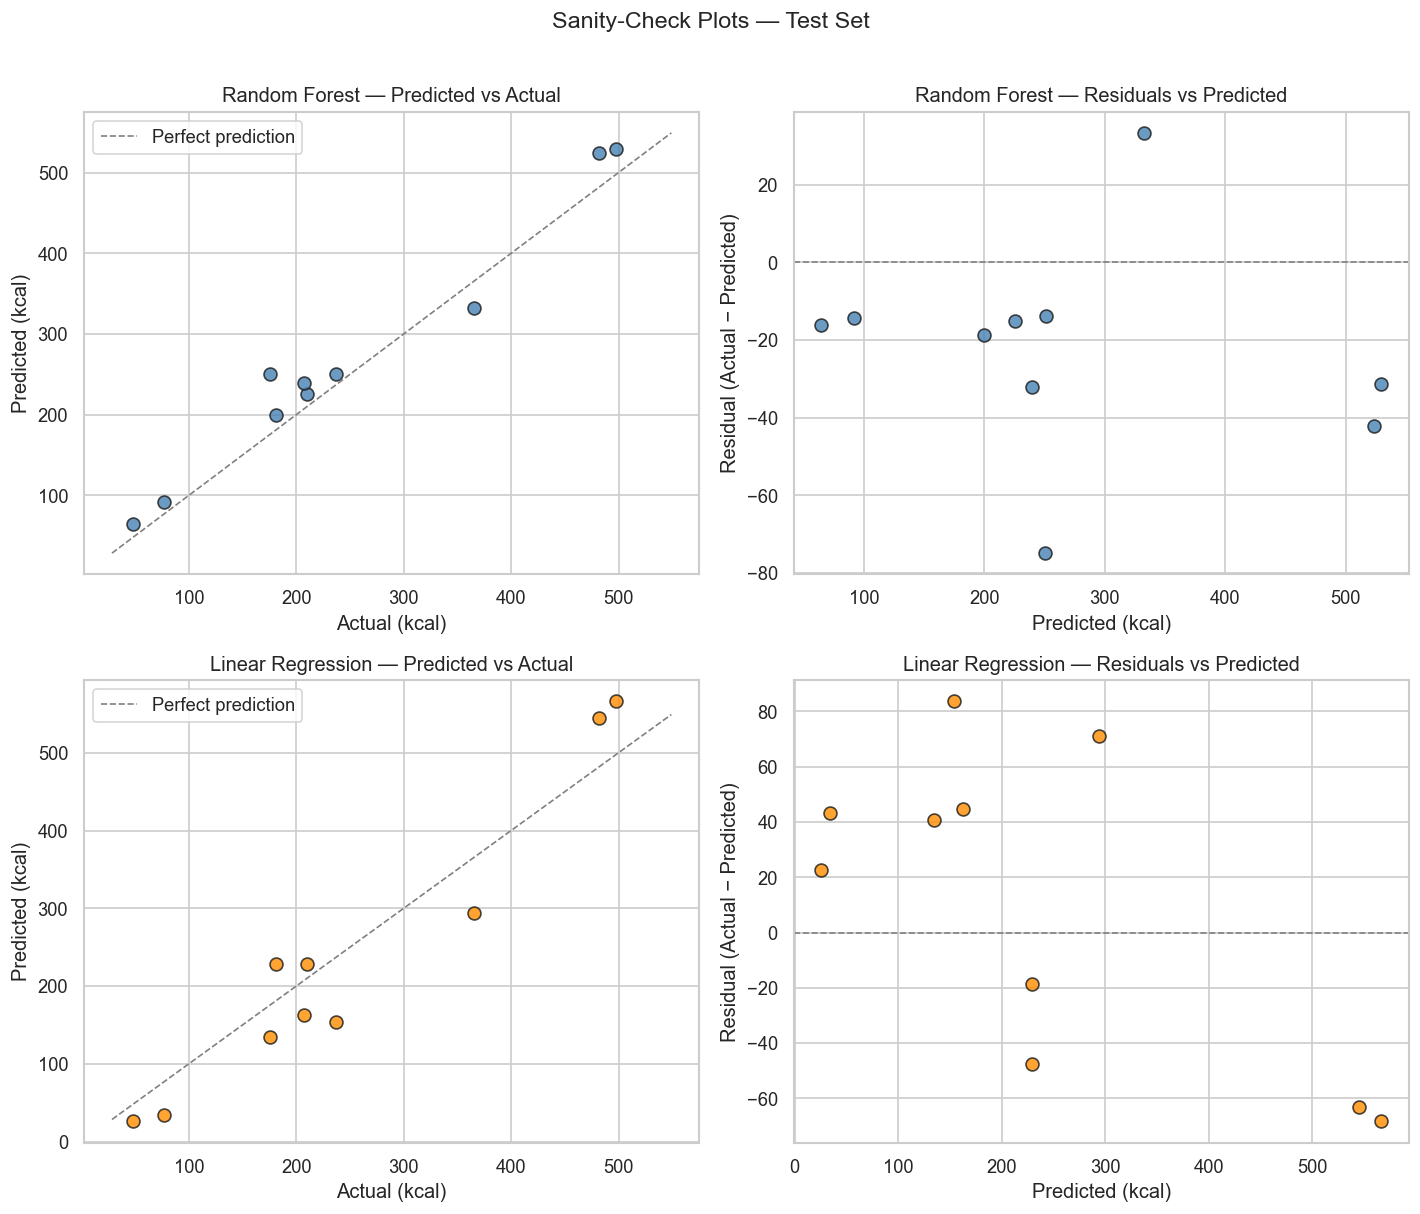

In [216]:
# Sanity-Check Plots (test set)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Random Forest ---
axes[0, 0].scatter(y_test, rf_pred, alpha=0.8, edgecolors="k", s=60, c="steelblue")
lims = [min(y_test.min(), min(rf_pred)) - 20, max(y_test.max(), max(rf_pred)) + 20]
axes[0, 0].plot(lims, lims, "--", color="grey", lw=1, label="Perfect prediction")
axes[0, 0].set_xlabel("Actual (kcal)")
axes[0, 0].set_ylabel("Predicted (kcal)")
axes[0, 0].set_title("Random Forest — Predicted vs Actual")
axes[0, 0].legend()

rf_resid = y_test.values - rf_pred
axes[0, 1].scatter(rf_pred, rf_resid, alpha=0.8, edgecolors="k", s=60, c="steelblue")
axes[0, 1].axhline(0, color="grey", ls="--", lw=1)
axes[0, 1].set_xlabel("Predicted (kcal)")
axes[0, 1].set_ylabel("Residual (Actual − Predicted)")
axes[0, 1].set_title("Random Forest — Residuals vs Predicted")

# --- Linear Regression ---
axes[1, 0].scatter(y_test, lr_pred, alpha=0.8, edgecolors="k", s=60, c="darkorange")
axes[1, 0].plot(lims, lims, "--", color="grey", lw=1, label="Perfect prediction")
axes[1, 0].set_xlabel("Actual (kcal)")
axes[1, 0].set_ylabel("Predicted (kcal)")
axes[1, 0].set_title("Linear Regression — Predicted vs Actual")
axes[1, 0].legend()

lr_resid = y_test.values - lr_pred
axes[1, 1].scatter(lr_pred, lr_resid, alpha=0.8, edgecolors="k", s=60, c="darkorange")
axes[1, 1].axhline(0, color="grey", ls="--", lw=1)
axes[1, 1].set_xlabel("Predicted (kcal)")
axes[1, 1].set_ylabel("Residual (Actual − Predicted)")
axes[1, 1].set_title("Linear Regression — Residuals vs Predicted")

plt.suptitle("Sanity-Check Plots — Test Set", fontsize=14, y=1.01)
plt.tight_layout()
savefig("residual_diagnostics", kind="model")
plt.show()

  Saved -> figures/model_predicted_vs_actual_dated.png


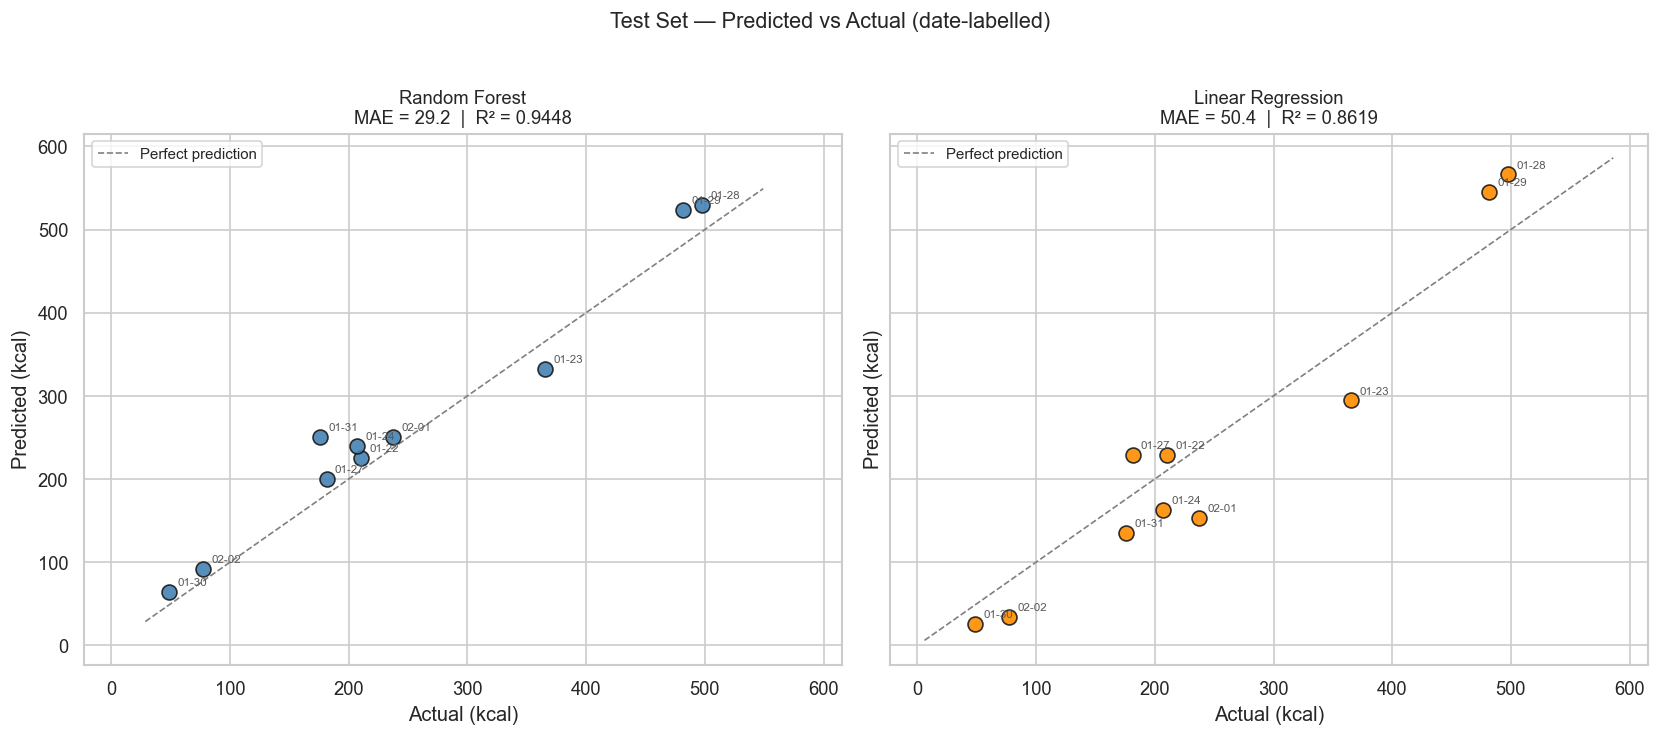

In [218]:
# Predicted vs Actual (date-labelled)
test_dates = test["date"].dt.strftime("%m-%d").values

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, (name, preds, color) in zip(axes, [
    ("Random Forest",      rf_pred,  "steelblue"),
    ("Linear Regression",  lr_pred,  "darkorange"),
]):
    ax.scatter(y_test, preds, s=80, c=color, edgecolors="k", alpha=0.9, zorder=3)
    lo = min(y_test.min(), min(preds)) - 20
    hi = max(y_test.max(), max(preds)) + 20
    ax.plot([lo, hi], [lo, hi], "--", color="grey", lw=1, label="Perfect prediction")
    for xi, yi, lbl in zip(y_test, preds, test_dates):
        ax.annotate(lbl, (xi, yi), fontsize=7, ha="left",
                    xytext=(5, 4), textcoords="offset points", color="0.35")
    mae = mean_absolute_error(y_test, preds)
    r2  = r2_score(y_test, preds)
    ax.set_title(f"{name}\nMAE = {mae:.1f}  |  R² = {r2:.4f}", fontsize=11)
    ax.set_xlabel("Actual (kcal)")
    ax.set_ylabel("Predicted (kcal)")
    ax.legend(loc="upper left", fontsize=9)

fig.suptitle("Test Set — Predicted vs Actual (date-labelled)", fontsize=13, y=1.02)
plt.tight_layout()
savefig("predicted_vs_actual_dated", kind="model")
plt.show()

In [219]:
# Resting Energy Ablation (same-family feature risk)
REST_COL = "resting_energy_kcal"

if REST_COL in feature_cols:
    cols_without_rest = [c for c in feature_cols if c != REST_COL]
    print(f"Ablation: removing '{REST_COL}' from features")
    print(f"  With:    {len(feature_cols)} features")
    print(f"  Without: {len(cols_without_rest)} features\n")

    rest_rows = []
    for label, cols_set in [("With resting_energy", feature_cols),
                            ("Without resting_energy", cols_without_rest)]:
        Xtr = X_train[cols_set]
        Xte = X_test[cols_set]

        # Random Forest
        _rf = RandomForestRegressor(n_estimators=500, random_state=RANDOM_SEED)
        _rf.fit(Xtr, y_train)
        _rfp = _rf.predict(Xte)
        rest_rows.append({
            "config": label, "model": "RandomForest",
            "MAE": round(mean_absolute_error(y_test, _rfp), 2),
            "R2":  round(r2_score(y_test, _rfp), 4),
            "n_test": len(y_test),
        })

        # Linear Regression
        _lr = LinearRegression()
        _lr.fit(Xtr, y_train)
        _lrp = _lr.predict(Xte)
        rest_rows.append({
            "config": label, "model": "LinearRegression",
            "MAE": round(mean_absolute_error(y_test, _lrp), 2),
            "R2":  round(r2_score(y_test, _lrp), 4),
            "n_test": len(y_test),
        })

    rest_df = pd.DataFrame(rest_rows)
    print("=== Resting Energy Ablation ===")
    print(rest_df.to_string(index=False))

    # Interpretation — robust extraction with explicit delta direction
    _rf_with_rows = rest_df[
        (rest_df["config"] == "With resting_energy")
        & (rest_df["model"] == "RandomForest")
    ]
    _rf_wo_rows = rest_df[
        (rest_df["config"] == "Without resting_energy")
        & (rest_df["model"] == "RandomForest")
    ]

    if _rf_with_rows.empty or _rf_wo_rows.empty:
        print("\n Could not locate both RF rows in rest_df — "
              "skipping delta interpretation.")
    else:
        rf_with = _rf_with_rows.iloc[0]
        rf_wo   = _rf_wo_rows.iloc[0]
        delta   = rf_with["R2"] - rf_wo["R2"]
        print(f"\n• RF R² WITH resting_energy:    {rf_with['R2']:.4f}")
        print(f"• RF R² WITHOUT resting_energy: {rf_wo['R2']:.4f}")
        print(f"• Δ R² = (With) − (Without) = "
              f"{rf_with['R2']:.4f} − {rf_wo['R2']:.4f} = {delta:+.4f}")
        if abs(delta) < 0.02:
            print("  → Negligible change — resting_energy_kcal does NOT "
                  "inflate R².")
            print("    It is a legitimate same-day physiology feature, "
                  "not leakage.")
        elif delta > 0:
            print("  → Modest positive contribution; feature adds signal "
                  "but is not solely responsible for high R².")
        else:
            print("  → Removing it slightly improves R² — no leakage "
                  "concern.")
else:
    print(f"'{REST_COL}' not in feature_cols — ablation not applicable.")

Ablation: removing 'resting_energy_kcal' from features
  With:    19 features
  Without: 18 features

=== Resting Energy Ablation ===
                config            model   MAE     R2  n_test
   With resting_energy     RandomForest 29.19 0.9448      10
   With resting_energy LinearRegression 50.37 0.8619      10
Without resting_energy     RandomForest 29.71 0.9378      10
Without resting_energy LinearRegression 50.34 0.8621      10

• RF R² WITH resting_energy:    0.9448
• RF R² WITHOUT resting_energy: 0.9378
• Δ R² = (With) − (Without) = 0.9448 − 0.9378 = +0.0070
  → Negligible change — resting_energy_kcal does NOT inflate R².
    It is a legitimate same-day physiology feature, not leakage.


In [220]:
# FINAL SHIP-IT CHECK 
#   rf_pred    = pd.Series(rf.predict(X_test),    index=y_test.index, name="rf_pred")
#   lr_pred    = pd.Series(lr.predict(X_test),    index=y_test.index, name="lr_pred")
#   dummy_pred = pd.Series(dummy.predict(X_test), index=y_test.index, name="dummy_pred")
#   naive_pred = pd.Series(naive_pred,            index=y_test.index, name="naive_pred")


def FINAL_SHIP_IT_CHECK():
    """Single-run defensibility gate. Raises AssertionError on any FAIL."""
    import numpy as np
    from collections import OrderedDict
    verdicts = OrderedDict()

    # Safe default
    try:
        _exp = EXPECTED_N_TEST
    except NameError:
        _exp = 10

    print("=" * 62)
    print("FINAL SHIP-IT CHECK")
    print("=" * 62)

    # Dates unique & sorted
    uniq = mdf["date"].is_unique
    srtd = mdf["date"].is_monotonic_increasing
    verdicts["Dates unique"] = uniq
    verdicts["Dates sorted"] = srtd
    print(f"\n  1. Dates unique: {'PASS ✅' if uniq else 'FAIL ❌'}")
    print(f"     Dates sorted: {'PASS ✅' if srtd else 'FAIL ❌'}")

    # Target not in features
    tgt_safe = TARGET not in feature_cols
    verdicts["Target ∉ features"] = tgt_safe
    print(f"  2. TARGET ('{TARGET}') not in feature_cols: "
          f"{'PASS ✅' if tgt_safe else 'FAIL ❌'}")

    # Train/test date ranges + chronological
    tr0 = train["date"].min().date()
    tr1 = train["date"].max().date()
    te0 = test["date"].min().date()
    te1 = test["date"].max().date()
    chrono = train["date"].max() < test["date"].min()
    verdicts["Chronological split"] = chrono
    print(f"  3. Train: n={len(train)} | {tr0} → {tr1}")
    print(f"     Test:  n={len(test)} | {te0} → {te1}")
    print(f"     Chronological: {'PASS ✅' if chrono else 'FAIL ❌'}")

    # No index overlap + strict index alignment
    ovlp = set(X_train.index) & set(X_test.index)
    no_ovlp = len(ovlp) == 0
    # Strict: same index objects (values + order), not just same length
    idx_train_ok = X_train.index.equals(y_train.index)
    idx_test_ok  = X_test.index.equals(y_test.index)
    verdicts["No index overlap"]       = no_ovlp
    verdicts["X_train↔y_train index"]  = idx_train_ok
    verdicts["X_test↔y_test index"]    = idx_test_ok
    print(f"  4. No overlap: {'PASS ✅' if no_ovlp else 'FAIL ❌'}")
    print(f"     X_train.index ≡ y_train.index: "
          f"{'PASS ✅' if idx_train_ok else 'FAIL ❌'}")
    print(f"     X_test.index  ≡ y_test.index:  "
          f"{'PASS ✅' if idx_test_ok else 'FAIL ❌'}")

    # No NaNs
    nans = {
        "X_train": int(X_train.isna().sum().sum()),
        "X_test":  int(X_test.isna().sum().sum()),
        "y_train": int(y_train.isna().sum()),
        "y_test":  int(y_test.isna().sum()),
    }
    nan_free = all(v == 0 for v in nans.values())
    verdicts["No NaNs at fit-time"] = nan_free
    print(f"  5. NaN-free: {'PASS ✅' if nan_free else 'FAIL ❌'} {nans}")

    # Ablation n_test == len(y_test)
    try:
        _abl_vals = abl_df["n_test"].unique().tolist()
        abl_ok = (len(_abl_vals) == 1) and (_abl_vals[0] == len(y_test))
        verdicts["abl_df n_test == len(y_test)"] = abl_ok
        print(f"  6. abl_df n_test unique={_abl_vals}, "
              f"== len(y_test)={len(y_test)}: "
              f"{'PASS ✅' if abl_ok else 'FAIL ❌'}")
    except NameError:
        print("  6. abl_df not found — SKIP")

    # Metrics — SAME TEST ROWS (hardened)
    print("  7. Metrics — same test rows:")

    # y_test size == EXPECTED_N_TEST
    _sz = len(y_test) == _exp
    verdicts[f"len(y_test) == {_exp}"] = _sz
    print(f"     a. len(y_test)=={_exp}: "
          f"{'PASS ✅' if _sz else 'FAIL ❌'}")

    # Per-prediction alignment — must be pd.Series with matching index
    _g = globals()
    _pred_names = ["rf_pred", "lr_pred", "dummy_pred", "naive_pred"]
    _found = 0
    for _nm in _pred_names:
        if _nm not in _g:
            continue
        _arr = _g[_nm]
        _found += 1
        if not isinstance(_arr, pd.Series):
            verdicts[f"{_nm} is Series"] = False
            print(f"     b. {_nm}: NOT a pd.Series → FAIL ❌")
            continue
        _ok = (_arr.index.equals(y_test.index)
               and len(_arr) == len(y_test))
        verdicts[f"{_nm} index≡y_test"] = _ok
        tag = "PASS ✅" if _ok else "FAIL ❌"
        print(f"     b. {_nm}: Series index≡y_test.index, "
              f"len={len(_arr)} → {tag}")
    if _found == 0:
        print("     b. No pred arrays found — SKIP")

    # RF MAE spot-check: recompute, assert finite & ≥ 0,
    #     cross-check against comp_df (exact index "RandomForest")
    if "rf_pred" in _g:
        _rfp = _g["rf_pred"]
        _re_mae = mean_absolute_error(y_test, _rfp)
        _finite = np.isfinite(_re_mae) and _re_mae >= 0
        verdicts["RF MAE finite & ≥ 0"] = _finite
        _msg = f"recomputed={_re_mae:.2f}"

        # Cross-check against comp_df — FAIL (not SKIP) if comp_df
        # exists but the row or column is missing.
        try:
            assert "MAE" in comp_df.columns, (
                "comp_df exists but has no 'MAE' column")
            assert "RandomForest" in comp_df.index, (
                "comp_df exists but has no 'RandomForest' row")
            _stored = comp_df.loc["RandomForest", "MAE"]
            _tol_ok = abs(_re_mae - _stored) < 0.01
            verdicts["RF MAE matches comp_df"] = _tol_ok
            _msg += (f" vs comp_df={_stored:.2f} "
                     f"{'MATCH ✅' if _tol_ok else 'MISMATCH ❌'}")
        except NameError:
            _msg += " | comp_df not defined — SKIP"
        except AssertionError as e:
            verdicts["RF MAE matches comp_df"] = False
            _msg += f" | FAIL: {e}"

        tag = "PASS ✅" if _finite else "FAIL ❌"
        print(f"     c. RF MAE spot-check: {_msg} → {tag}")
    else:
        print("     c. rf_pred not found — SKIP MAE spot-check")

    # rest_df n_test == len(y_test)
    try:
        _r_ok = all(rest_df["n_test"] == len(y_test))
        verdicts["rest_df n_test == len(y_test)"] = _r_ok
        print(f"     d. rest_df n_test all=={len(y_test)}: "
              f"{'PASS ✅' if _r_ok else 'FAIL ❌'}")
    except NameError:
        print("     d. rest_df not found — SKIP")

    # Top-10 RF feature importances (informational)
    try:
        top10 = importances.sort_values(ascending=False).head(10)
        print(f"\n RF Top-10 Feature Importances:")
        for rank, (feat, imp) in enumerate(top10.items(), 1):
            print(f"     {rank:2d}. {feat:<30s} {imp:.4f}")
    except NameError:
        print("\n RF importances not found — SKIP")

    print(f"\n{'=' * 62}")
    failures = [k for k, v in verdicts.items() if not v]
    if failures:
        for f in failures:
            print(f"  ❌ FAIL: {f}")
        raise AssertionError(
            f"SHIP-IT CHECK FAILED on {len(failures)} item(s): {failures}"
        )
    else:
        print("  ✅ ALL CHECKS PASSED — SHIP IT.")
        print("=" * 62)

In [221]:
FINAL_SHIP_IT_CHECK()

FINAL SHIP-IT CHECK

  1. Dates unique: PASS ✅
     Dates sorted: PASS ✅
  2. TARGET ('active_energy_kcal') not in feature_cols: PASS ✅
  3. Train: n=36 | 2025-11-25 → 2026-01-21
     Test:  n=10 | 2026-01-22 → 2026-02-02
     Chronological: PASS ✅
  4. No overlap: PASS ✅
     X_train.index ≡ y_train.index: PASS ✅
     X_test.index  ≡ y_test.index:  PASS ✅
  5. NaN-free: PASS ✅ {'X_train': 0, 'X_test': 0, 'y_train': 0, 'y_test': 0}
  6. abl_df n_test unique=[10], == len(y_test)=10: PASS ✅
  7. Metrics — same test rows:
     a. len(y_test)==10: PASS ✅
     b. rf_pred: Series index≡y_test.index, len=10 → PASS ✅
     b. lr_pred: Series index≡y_test.index, len=10 → PASS ✅
     b. dummy_pred: Series index≡y_test.index, len=10 → PASS ✅
     b. naive_pred: Series index≡y_test.index, len=10 → PASS ✅
     c. RF MAE spot-check: recomputed=29.19 vs comp_df=29.19 MATCH ✅ → PASS ✅
     d. rest_df n_test all==10: PASS ✅

 RF Top-10 Feature Importances:
      1. stand_hours                    0.4480


In [222]:
# Namespace Cleanup (optional — readability only)
# Remove temporary loop/scratch variables that clutter the kernel namespace.
# This does NOT affect any results; downstream cells reference only named
# DataFrames (comp_df, abl_df, cv_df, rest_df) and model objects.
_cleanup_names = [
    "c", "i", "col", "cl", "tag", "v", "xi", "yi", "lbl",
    "label", "color", "name", "msg", "word", "reason",
    "cnt", "check", "passed", "bl_name", "bl_pred",
    "config_name", "cols", "cols_set", "col_lower",
    "x_name", "y_name", "x_obj", "y_obj", "obj",
    "_rf", "_lr", "_rfp", "_lrp",
]
_deleted = []
for _n in _cleanup_names:
    if _n in dir():
        try:
            exec(f"del {_n}")
            _deleted.append(_n)
        except Exception:
            pass
print(f"🧹 Cleaned {len(_deleted)} temporary variables: {_deleted[:10]}"
      + (f" … +{len(_deleted)-10} more" if len(_deleted) > 10 else ""))

🧹 Cleaned 22 temporary variables: ['c', 'i', 'col', 'cl', 'v', 'xi', 'yi', 'lbl', 'label', 'color'] … +12 more


---
## Results Summary (See Paper for Full Discussion)

### Headline Results

- **Steps ↔ Active Energy:** Very strong Pearson $$r$$ (see Phase 3 output); Spearman $$\rho$$ confirms robustness to non-normality.
- **Weekday vs. Weekend:** Welch's $$t$$-test non-significant with small Cohen's $$d$$ (see Phase 3) — active energy comparable across day types in this sample.
- **Random Forest outperforms all baselines:** Lowest MAE and highest $$R^2$$ on the test set (see Phase 4 comparison table). Linear Regression also beats both Dummy and Naive baselines.
- **Top predictors:** Same-day `stand_hours` and `steps` dominate feature importance; lag-1 features rank near the bottom (see Phase 4 bar chart) — consistent with the same-day explanatory framing.
- **Cross-validated estimate:** Walk-forward CV (Phase 4 CV table) provides a more conservative generalisation estimate than the single 80/20 split; interpret the headline test-set $$R^2$$ as a best-case upper bound.
- **Robustness checks passed:** No leakage detected; ablation studies show performance depends on physically meaningful activity features; residual diagnostics show no systematic bias (see Phase 4 outputs).
- **Data quality:** Meters-per-step distribution within expected range; no outlier removal required (Phase 1).

### Key Limitations

- **Short observation window** — limits generalisability and seasonal pattern detection.
- **Single participant** — findings may not transfer to other individuals or populations.
- **Autocorrelation** — daily health metrics are serially correlated; $$p$$-values are descriptive, not strictly confirmatory.
- **Complete-case bias** — modeling uses only rows surviving `dropna`; missingness may correlate with lower-activity days.
- **Extended physiology missingness** — HRV, respiratory rate, and walking metrics have substantial gaps; excluded from modeling.
- **Same-day framing, not forecasting** — the model cannot predict tomorrow's energy; it explains today's after observations are complete.

### Closing Remark

This notebook demonstrates an end-to-end pipeline from raw Apple Health exports to curated daily datasets, exploratory analysis, hypothesis testing, and same-day explanatory modeling. All results should be interpreted in context of the limitations above — particularly the short window and single-participant design.

For the full formal methodology, extended discussion, and references, see *Modeling_the_Relationship_Between_Daily_Activity_Metrics_and_Apple_Health_Active_Energy.pdf*.